# 🧪 آزمایشگاه HIPO — پژوهش استراتژی تیک‌به‌تیک EURUSD
**هدف کاربر:** بازده ۳ تا ۴٪ ماهانه با حداکثر افت سرمایه (DD) کمتر از ۱۰٪ روی یک جفت‌ارز.
**داده:** تیک واقعی bid/ask (Dukascopy) از ژانویه ۲۰۱۷ تا ۸ ژوئیه ۲۰۲۲ — حدود ۱۴۰ میلیون تیک.

## خلاصه‌ی نتیجه (صادقانه و قبل از هر جزئیات)
> **هدف ۳–۴٪ ماهانه با DD زیر ۱۰٪ در این پژوهش برآورده نشد.**

| بخش | نتیجه (اعداد از همین دفترچه) |
|---|---|
| بهترین کاندید | **M1 — متا-برچسب** روی سیگنال‌های چهار خانواده‌ی قانون‌محور (انتخاب فقط با داده‌ی پژوهش ۲۰۱۸–۲۰۲۰) |
| holdout (۲۰۲۱-۰۱ تا ۲۰۲۲-۰۶، بدون دیدن قبلی) | بازده کل **+4.8%**، میانگین ماهانه **+0.27%**، DD تیک‌به‌تیک **5.8%** (ریسک ۰.۵٪ هر معامله)، ۱۷۲ معامله |
| معناداری آماری | t-stat میانگین R = **0.72** (p≈0.47)، **DSR ≈ 0** پس از احتساب ۵۶ آزمون |
| مرز ریسک/بازده | با DD زیر ۱۰٪: ریسک ۰.۵٪ → ۰.۲۷٪ ماهانه (DD ۵.۸٪)؛ ریسک ۱٪ → ۰.۶۲٪ ماهانه ولی DD ۱۱.۴٪. یعنی سقف واقعی حدود **۰.۳ تا ۰.۴٪ ماهانه** است (تخمین درون‌یابی بین دو نقطه)؛ در ریسک ۳٪، میانگین ماهانه ۱.۵٪ با DD ≈ ۳۰٪ |
| حساسیت هزینه | اسپرد ×۲ → بازده holdout از ۴.۸٪ به ۲.۵٪؛ کمیسیون ۷ دلار → ۰.۷٪ |
| خانواده‌های قانون‌محور و ML مستقیم | در walk-forward پژوهش زیان‌ده‌اند؛ ML مستقیم (M2) حدود −۶۹٪ |

**چرا ۳–۴٪ ماهانه با DD زیر ۱۰٪ بعید است؟** ۳٪ ماهانه معادل ≈ ۴۳٪ سالانه‌ی مرکب است. برای داشتن این بازده با DD زیر ۱۰٪، نسبت بازده به DD (Calmar) باید حدود ۴ تا ۵ باشد. بیشتر استراتژی‌های سیستماتیک منتشرشده‌ی ارز در نمونه‌ی خارج از نمونه به Sharpe حدود ۰.۵ تا ۱ می‌رسند؛ و این دفترچه هزینه‌ی واقعی (اسپرد، اسلیپیج، کمیسیون، تأخیر) را در هر معامله اعمال می‌کند.

## ساختار دفترچه
1. **داده** — دانلود تیک (سلول ۱، روش HIPO) و فروشگاه تیک
2. **موتور تیک‌به‌تیک** — هسته‌ی numba، نوارسازی و اندیکاتورها
3. **کنترل کیفیت داده**
4. **پروتکل ارزیابی** — پژوهش (walk-forward)، holdout، embargo، کلید خاموشی
5. **سیگنال‌های قانون‌محور** (F1 تا F4) و walk-forward آن‌ها
6. **یادگیری ماشین** (M2 مستقیم، M1 متا-برچسب) با برچسب سه‌مانعه‌ای از مسیر تیک
7. **انتخاب، PBO و DSR** (بدون هیچ انتخابی روی holdout)
8. **مرز ریسک/بازده** و بررسی هدف
9. **🏁 سلول نهایی:** بک‌تستر حرفه‌ای تیک‌به‌تیک با گزارش جامع

**نیازمندی‌ها:** Python 3.10 یا بالاتر، pandas نسخه‌ی ۲.۲ یا بالاتر، numba، scikit-learn، scipy، matplotlib، requests، beautifulsoup4 (در Colab همه موجودند). حافظه‌ی حدود ۴ گیگابایت و حدود ۳ گیگابایت فضای کش. اجرای کامل حدود ۴ دقیقه پس از دانلود داده طول می‌کشد.

> ⚠️ این دفترچه مشاوره‌ی سرمایه‌گذاری نیست. نتایج بک‌تست، تضمین بازده‌ی آینده نیستند.

## ۱. داده: دانلود تیک واقعی (سلول ۱ — روش HIPO LABORATORY)
- **روش اصلی HIPO** (HistData با فرم `file_down` و `get.php`) در کد حفظ شده و با `SOURCE = "histdata"` قابل اجراست. از محیط آزمایشی ما دسترسی به histdata.com مسدود است، پس این مسیر **در اینجا آزموده نشد**؛ در Colab امتحان کنید.
- **منبع پیش‌فرض (هم‌ارز و قابل‌دسترس):** آرشیو تیک‌های Dukascopy در مخزن `FX-Data/FX-Data-EURUSD-DS` (هر سال یک شاخه‌ی Git، فایل‌های ساعتی CSV با `bid, ask` و میلی‌ثانیه). داده به‌صورت جریانی (stream) خوانده، با پارسر numba پردازش و به‌صورت ماهانه ذخیره می‌شود؛ هیچ فایل خامی در مخزن نمی‌ماند.
- **پاک‌سازی:** قیمت‌های متقاطع (bid > ask) و نامعتبر حذف می‌شوند؛ تکراری‌های دقیق حذف می‌شوند.
- **ماه ۲۰۲۲-۰۷** فقط ۸ روز دارد و در holdout استفاده نمی‌شود.
- **نکته‌ی داده:** تراکم تیک در ۲۰۲۱ حدود نصف ۲۰۲۰ است. این تغییر ساختاری داده است و در گزارش نهایی به آن اشاره می‌شود.

In [1]:
# ==================================================================================
# HIPO LABORATORY · Cell 1 — دانلود داده تیک واقعی و ساخت فروشگاه تیک (EURUSD)
# منبع پیش‌فرض: آینه‌ی تیک‌های Dukascopy در GitHub (FX-Data/FX-Data-EURUSD-DS)
# منبع جایگزین: HistData با همان روش سلول اول Ai.ipynb (در محیط آزمایش ما مسدود است)
# ==================================================================================
import os, io, glob, json, time, zipfile, tarfile, subprocess, datetime as dt
import numpy as np
import pandas as pd
from numba import njit

PAIR = "EURUSD"
SOURCE = "fxdata"            # "fxdata" (پیش‌فرض، Dukascopy) | "histdata" (روش اصلی HIPO)
YEARS = list(range(2017, 2023))  # 2022 ناقص است و تا 2022-07-08 ادامه دارد
CACHE_DIR = "/content/hipo_tick_cache" if os.path.isdir("/content") else "/tmp/hipo_tick_cache"
FORCE_REBUILD = False        # True = دوباره دانلود و بازسازی
PRICE_SCALE = 100000         # EURUSD: 5 رقم اعشار -> نقطه‌ی صحیح (points)

os.makedirs(CACHE_DIR, exist_ok=True)
MONTH_DIR = os.path.join(CACHE_DIR, "months")
FULL_DIR = os.path.join(CACHE_DIR, "full")
os.makedirs(MONTH_DIR, exist_ok=True)
os.makedirs(FULL_DIR, exist_ok=True)


@njit(cache=True)
def _days_from_civil(y, m, d):
    y -= 1 if m <= 2 else 0
    era = (y if y >= 0 else y - 399) // 400
    yoe = y - era * 400
    doy = (153 * (m + (-3 if m > 2 else 9)) + 2) // 5 + d - 1
    doe = yoe * 365 + yoe // 4 - yoe // 100 + doy
    return era * 146097 + doe - 719468


@njit(cache=True)
def parse_tick_csv(buf, scale):
    """پارس بایت‌به‌بایت CSV تیک. هر دو قالب زیر پشتیبانی می‌شوند:
    'YYYY.MM.DD HH:MM:SS.mmm,bid,ask,vol,vol'  (FX-Data / Dukascopy)
    'YYYYMMDD HHMMSSmmm,bid,ask,vol'            (HistData)
    خروجی: ts (ms UTC), bid/ask (int64 points)، bv/av (float32)."""
    n = buf.shape[0]
    cap = 1
    for k in range(n):
        if buf[k] == 10:
            cap += 1
    ts = np.empty(cap, np.int64)
    bid = np.empty(cap, np.int64)
    ask = np.empty(cap, np.int64)
    bv = np.empty(cap, np.float32)
    av = np.empty(cap, np.float32)
    cnt = 0
    i = 0
    while i < n:
        digs = np.int64(0)
        nd = 0
        bad = False
        while i < n and buf[i] != 44:
            c = buf[i]
            if c == 10:
                bad = True
                break
            if 48 <= c <= 57:
                if nd < 17:
                    digs = digs * 10 + (c - 48)
                nd += 1
            i += 1
        if bad or i >= n:
            while i < n and buf[i] != 10:
                i += 1
            i += 1
            continue
        i += 1
        if nd != 17:
            while i < n and buf[i] != 10:
                i += 1
            i += 1
            continue
        ms = digs % 1000
        t = digs // 1000
        ss = t % 100
        t //= 100
        mi = t % 100
        t //= 100
        hh = t % 100
        t //= 100
        dd = t % 100
        t //= 100
        mo = t % 100
        t //= 100
        yy = t
        days = _days_from_civil(yy, mo, dd)
        ts_val = (days * 86400 + hh * 3600 + mi * 60 + ss) * 1000 + ms
        vals = np.zeros(4, np.float64)
        ok = True
        for f in range(4):
            ip = np.int64(0)
            fp = np.int64(0)
            fd = 0
            seen_dot = False
            nd2 = 0
            while i < n and buf[i] != 44 and buf[i] != 10 and buf[i] != 13:
                c = buf[i]
                if c == 46:
                    seen_dot = True
                elif 48 <= c <= 57:
                    if seen_dot:
                        if fd < 9:
                            fp = fp * 10 + (c - 48)
                            fd += 1
                    else:
                        ip = ip * 10 + (c - 48)
                    nd2 += 1
                else:
                    ok = False
                i += 1
            if nd2 == 0 and f < 2:
                ok = False
            v = np.float64(ip)
            if fd > 0:
                p10 = 1.0
                for _ in range(fd):
                    p10 *= 10.0
                v += np.float64(fp) / p10
            vals[f] = v
            if i < n and buf[i] == 44:
                i += 1
        while i < n and buf[i] != 10:
            i += 1
        i += 1
        if not ok:
            continue
        ts[cnt] = ts_val
        bid[cnt] = np.int64(np.floor(vals[0] * scale + 0.5))
        ask[cnt] = np.int64(np.floor(vals[1] * scale + 0.5))
        bv[cnt] = np.float32(vals[2])
        av[cnt] = np.float32(vals[3])
        cnt += 1
    return ts[:cnt], bid[:cnt], ask[:cnt], bv[:cnt], av[:cnt]


def _iter_fxdata_year(year):
    """هر فایل ساعتی تیک را از شاخه‌ی سال در آرشیو tar.gz (بدون ذخیره‌ی کامل روی دیسک) برمی‌گرداند."""
    url = f"https://codeload.github.com/FX-Data/FX-Data-EURUSD-DS/tar.gz/refs/heads/EURUSD-{year}"
    proc = subprocess.Popen(["curl", "-sSfL", "--retry", "3", "--retry-delay", "5", "-m", "3000", url],
                            stdout=subprocess.PIPE)
    tf = tarfile.open(fileobj=proc.stdout, mode="r|gz")
    n_files = 0
    for m in tf:
        if m.isfile() and m.name.endswith("_ticks.csv"):
            n_files += 1
            data = tf.extractfile(m).read()
            if data:
                yield data
    tf.close()
    rc = proc.wait()
    if rc != 0 or n_files == 0:
        raise RuntimeError(f"دانلود سال {year} ناموفق بود (rc={rc}, files={n_files})")


def _iter_histdata_month(pair, year, month):
    """روش اصلی HIPO: صفحه‌ی HistData -> فرم file_down -> get.php -> ZIP -> CSV."""
    import requests
    from bs4 import BeautifulSoup
    headers = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36',
               'Referer': 'http://www.histdata.com/'}
    sess = requests.Session()
    page = f"http://www.histdata.com/download-free-forex-historical-data/?/ascii/tick-data-quotes/{pair.lower()}/{year}/{month}"
    soup = BeautifulSoup(sess.get(page, timeout=20, headers=headers).content, 'html.parser')
    form = soup.find('form', {'id': 'file_down'})
    if not form:
        return None
    payload = {tag.get('name'): tag.get('value') for tag in form.find_all('input')}
    resp = sess.post("http://www.histdata.com/get.php", data=payload, timeout=120, headers=headers)
    if resp.status_code != 200:
        return None
    with zipfile.ZipFile(io.BytesIO(resp.content)) as z:
        return z.read(z.namelist()[0])


def _flush_parts(year, buckets):
    for k, chunks in buckets.items():
        ts = np.concatenate([c[0] for c in chunks])
        bid = np.concatenate([c[1] for c in chunks])
        ask = np.concatenate([c[2] for c in chunks])
        y, mo = 1970 + k // 12, k % 12 + 1
        np.savez(os.path.join(MONTH_DIR, f"{y}{mo:02d}_part{year}_{time.time_ns()}.npz"), ts=ts, bid=bid, ask=ask)


def _bucket_add(buckets, ts, bid, ask):
    mk = (ts // 1000).astype("datetime64[s]").astype("datetime64[M]").astype(np.int64)
    for k in np.unique(mk):
        sel = mk == k
        buckets.setdefault(int(k), []).append((ts[sel], bid[sel].astype(np.int32), ask[sel].astype(np.int32)))


def download_and_parse(years, source):
    qa = {"raw_rows": 0, "crossed_dropped": 0}
    for y in years:
        t0 = time.time()
        buckets = {}
        if source == "fxdata":
            blocks = _iter_fxdata_year(y)
            for data in blocks:
                ts, bid, ask, _, _ = parse_tick_csv(np.frombuffer(data, dtype=np.uint8), float(PRICE_SCALE))
                qa["raw_rows"] += len(ts)
                bad = (bid > ask) | (bid <= 0) | (ask <= 0)
                qa["crossed_dropped"] += int(bad.sum())
                if (~bad).any():
                    _bucket_add(buckets, ts[~bad], bid[~bad], ask[~bad])
        else:
            for mo in range(1, 13):
                if y == dt.date.today().year and mo > dt.date.today().month:
                    break
                data = _iter_histdata_month(PAIR, y, mo)
                if not data:
                    print(f"  HistData {y}-{mo:02d}: no data")
                    continue
                ts, bid, ask, _, _ = parse_tick_csv(np.frombuffer(data, dtype=np.uint8), float(PRICE_SCALE))
                qa["raw_rows"] += len(ts)
                bad = (bid > ask) | (bid <= 0) | (ask <= 0)
                qa["crossed_dropped"] += int(bad.sum())
                if (~bad).any():
                    _bucket_add(buckets, ts[~bad], bid[~bad], ask[~bad])
        _flush_parts(y, buckets)
        print(f"  سال {y}: {time.time() - t0:.0f} ثانیه | ردیف خام تاکنون: {qa['raw_rows']:,}")
    return qa


def consolidate_months():
    """فایل‌های بخشی را برای هر ماه ادغام، مرتب و تکراری‌ها را حذف می‌کند؛ سپس آرایه‌های پیوسته می‌سازد."""
    parts = sorted(glob.glob(os.path.join(MONTH_DIR, "*_part*.npz")))
    by_month = {}
    for f in parts:
        by_month.setdefault(os.path.basename(f)[:6], []).append(f)
    qa_month = {}
    for ym, fl in sorted(by_month.items()):
        ts_l, b_l, a_l = [], [], []
        for f in fl:
            with np.load(f) as z:
                ts_l.append(z["ts"]); b_l.append(z["bid"]); a_l.append(z["ask"])
        ts = np.concatenate(ts_l); bid = np.concatenate(b_l); ask = np.concatenate(a_l)
        o = np.argsort(ts, kind="stable")
        ts, bid, ask = ts[o], bid[o], ask[o]
        dup = np.zeros(len(ts), dtype=bool)
        dup[1:] = (ts[1:] == ts[:-1]) & (bid[1:] == bid[:-1]) & (ask[1:] == ask[:-1])
        qa_month[ym] = {"rows": int((~dup).sum()), "duplicates_dropped": int(dup.sum())}
        np.savez(os.path.join(MONTH_DIR, f"{ym}.npz"), ts=ts[~dup], bid=bid[~dup], ask=ask[~dup])
        for f in fl:
            os.remove(f)
    months = sorted(glob.glob(os.path.join(MONTH_DIR, "??????.npz")))
    lens = []
    for f in months:
        with np.load(f) as z:
            lens.append(len(z["ts"]))
    total = int(sum(lens))
    ts_m = np.lib.format.open_memmap(os.path.join(FULL_DIR, "ts.npy"), mode="w+", dtype=np.int64, shape=(total,))
    bid_m = np.lib.format.open_memmap(os.path.join(FULL_DIR, "bid.npy"), mode="w+", dtype=np.int32, shape=(total,))
    ask_m = np.lib.format.open_memmap(os.path.join(FULL_DIR, "ask.npy"), mode="w+", dtype=np.int32, shape=(total,))
    off = 0
    prev = None
    for f in months:
        with np.load(f) as z:
            ts, bid, ask = z["ts"], z["bid"], z["ask"]
        if prev is not None and len(ts):
            assert ts[0] >= prev, "ماه‌ها به ترتیب زمانی نیستند"
        ts_m[off:off + len(ts)] = ts
        bid_m[off:off + len(ts)] = bid
        ask_m[off:off + len(ts)] = ask
        off += len(ts)
        if len(ts):
            prev = ts[-1]
    ts_m.flush(); bid_m.flush(); ask_m.flush()
    meta = {"pair": PAIR, "source": SOURCE, "n_ticks": total,
            "first_utc": str(pd.to_datetime(int(ts_m[0]), unit="ms")),
            "last_utc": str(pd.to_datetime(int(ts_m[-1]), unit="ms")),
            "months": qa_month, "built_at": str(dt.datetime.utcnow())}
    with open(os.path.join(FULL_DIR, "meta.json"), "w") as fh:
        json.dump(meta, fh, indent=1)
    return meta


def load_store():
    """آرایه‌های تیک را به‌صورت memmap (بدون بارگذاری کامل در RAM) برمی‌گرداند."""
    ts = np.load(os.path.join(FULL_DIR, "ts.npy"), mmap_mode="r")
    bid = np.load(os.path.join(FULL_DIR, "bid.npy"), mmap_mode="r")
    ask = np.load(os.path.join(FULL_DIR, "ask.npy"), mmap_mode="r")
    return ts, bid, ask


# ---------------------------- اجرا ----------------------------
_have = os.path.exists(os.path.join(FULL_DIR, "meta.json")) and not FORCE_REBUILD
if _have:
    print("فروشگاه تیک از قبل ساخته شده است؛ دانلود تکراری انجام نمی‌شود.")
else:
    print(f"شروع دانلود {PAIR} از منبع: {SOURCE}")
    _qa = download_and_parse(YEARS, SOURCE)
    print("ادغام ماه‌ها و ساخت آرایه‌های یکپارچه ...")
    _meta = consolidate_months()
    print("ردیف‌های خام:", f"{_qa['raw_rows']:,}", "| قیمت متقاطع/نامعتبر حذف‌شده:", f"{_qa['crossed_dropped']:,}")

TS, BID, ASK = load_store()
META = json.load(open(os.path.join(FULL_DIR, "meta.json")))
if "first_utc" not in META:  # متادیتای قدیمی (ساخت توسعه): از روی آرایه‌ها بازسازی می‌شود
    META = {"pair": PAIR, "source": SOURCE, "n_ticks": int(len(TS)),
            "first_utc": str(pd.to_datetime(int(TS[0]), unit="ms")),
            "last_utc": str(pd.to_datetime(int(TS[-1]), unit="ms")),
            "months": {os.path.basename(f)[:6]: {"rows": int(np.load(f)["ts"].shape[0])}
                       for f in sorted(glob.glob(os.path.join(MONTH_DIR, "??????.npz")))},
            "built_at": str(dt.datetime.utcnow())}
    with open(os.path.join(FULL_DIR, "meta.json"), "w") as fh:
        json.dump(META, fh, indent=1)
print(f"تعداد کل تیک‌ها: {META['n_ticks']:,} | از {META['first_utc']} تا {META['last_utc']} (UTC)")
_yr = {}
for _k, _v in META["months"].items():
    _yr[_k[:4]] = _yr.get(_k[:4], 0) + _v["rows"]
display(pd.DataFrame({"ticks_million": {k: round(v / 1e6, 2) for k, v in _yr.items()}}).T)

شروع دانلود EURUSD از منبع: fxdata
  سال 2017: 43 ثانیه | ردیف خام تاکنون: 21,685,981
  سال 2018: 47 ثانیه | ردیف خام تاکنون: 47,713,773
  سال 2019: 54 ثانیه | ردیف خام تاکنون: 76,900,083
  سال 2020: 62 ثانیه | ردیف خام تاکنون: 109,663,721
  سال 2021: 28 ثانیه | ردیف خام تاکنون: 126,262,527
  سال 2022: 22 ثانیه | ردیف خام تاکنون: 139,801,242
ادغام ماه‌ها و ساخت آرایه‌های یکپارچه ...
ردیف‌های خام: 139,801,242 | قیمت متقاطع/نامعتبر حذف‌شده: 0
تعداد کل تیک‌ها: 139,801,242 | از 2017-01-01 22:00:20.786000 تا 2022-07-08 20:59:59.874000 (UTC)


/tmp/ipykernel_742/734655284.py:276: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "months": qa_month, "built_at": str(dt.datetime.utcnow())}


,2017,2018,2019,2020,2021,2022
ticks_million,21.69,26.03,29.19,32.76,16.6,13.54


## ۲. موتور بک‌تست تیک‌به‌تیک (هسته‌ی مشترک همه‌ی بخش‌ها)
**اصول:**
- **ورود** با `ask` (خرید) یا `bid` (فروش) در **اولین تیک پس از تأخیر ۱ ثانیه** از لحظه‌ی تصمیم؛ اگر اسپرد از سقف فیلتر (۲ pip) بیشتر باشد، ورود به تیک بعدی موکول می‌شود (پنجره‌ی ۳۰ ثانیه).
- **خروج** در تیک واقعی: SL، TP، سقف زمانی، یا بستن قبل از تعطیلات آخر هفته (جمعه ۲۰:۳۰ UTC). ورود جدید از جمعه ۲۰:۰۰ مسدود است.
- **اسلیپیج** ۰.۱ pip در هر طرف؛ **کمیسیون** ۳.۵ دلار به‌ازای هر لات در هر طرف؛ **اسپرد** از خود داده (بدون اسپرد ثابت).
- **اندازه‌ی پوزیشن:** ریسک درصدی از سرمایه‌ی لحظه‌ای، با سقف اهرم ۳۰:۱ و گرد کردن به ۰.۰۱ لات.
- **یک پوزیشن هم‌زمان**؛ سیگنال‌های رسیده در زمان باز بودن پوزیشن نادیده گرفته می‌شوند.
- **DD مارک‌تو‌مارکت در هر تیک** محاسبه می‌شود (نه فقط در بسته‌شدن معامله).
- **بهره‌ی شبانه (swap) نادیده گرفته شده** چون داده‌ی آن در دسترس نیست.
- **تحقق کامل:** موجودی نهایی دقیقاً برابر سرمایه‌ی اولیه + مجموع خالص سود معاملات است؛ این و چند بررسی دیگر در «خودآزمایی موتور» (بخش ۵) اجرا می‌شوند.

In [3]:
# ==================================================================================
# Cell 1b — موتور بک‌تست تیک‌به‌تیک (numba) + ساخت نوار از تیک + اندیکاتورها
# • ورود در قیمت ask (خرید) / bid (فروش) بعد از تأخیر (latency) و با اسلیپیج
# • SL/TP/Time-stop/بستن آخر هفته؛ اندازه‌ی پوزیشن بر اساس ریسک % و سقف اهرم
# • DD مارک‌تو‌مارکت در هر تیک محاسبه می‌شود (نه فقط در بسته‌شدن معامله)
# ==================================================================================
"""Tick-by-tick EURUSD backtest core (numba). Prices are stored as int 'points' (1e-5).
Conventions: ts = UTC epoch milliseconds. Long fills at ask, exits at bid; shorts the reverse.
"""
import numpy as np
from numba import njit

PTS = 100000.0            # price points per 1.0 (EURUSD: 5 decimals)
PIP = 1e-4                # 1 pip in price units
CONTRACT = 100000.0       # EURUSD standard lot in base currency
PIP_VALUE_LOT = 10.0      # USD per pip per standard lot (USD account)
MS_MIN = 60000
MS_HOUR = 3600000
MS_DAY = 86400000
MS_WEEK = 7 * MS_DAY

# engine parameter vector indices
P_EQ0 = 0        # starting equity (USD)
P_RISK = 1       # fraction of equity risked per trade
P_MAXLEV = 2     # max leverage (notional / equity)
P_COMM = 3       # commission USD per standard lot per side
P_SLIP = 4       # adverse slippage per fill, price units
P_LAT = 5        # latency between decision time and earliest fill (ms)
P_FILLWIN = 6    # max delay after latency for a fill (ms)
P_MAXSPREAD = 7  # skip entry if spread > this (price units); <=0 disables
P_NOENTRY_TOW = 8   # no new entries when time-of-week >= this (ms, 0=Mon 00:00 UTC)
P_FCLOSE_TOW = 9    # force-close open trades when time-of-week >= this
P_MINLOT = 10
P_LOTSTEP = 11
P_SPREADMULT = 12
P_NPARAM = 13

# trade record columns
TR_ENTRY_TS, TR_EXIT_TS, TR_DIR, TR_ENTRY, TR_EXIT, TR_LOTS, TR_GROSS, TR_COMM, TR_NET, TR_REASON, \
    TR_RISK, TR_SL, TR_TP, TR_MAE, TR_MFE, TR_SPREAD_IN, TR_SIG, TR_HOLD_MIN = range(18)
TR_NCOL = 18
EXIT_NAMES = {0: "SL", 1: "TP", 2: "TIME", 3: "WEEKEND", 4: "EOD"}


def default_params(equity=10_000.0, risk=0.005, max_lev=30.0, comm=3.5, slip_pips=0.1,
                   latency_ms=1000, fillwin_ms=30_000, max_spread_pips=2.0):
    p = np.zeros(P_NPARAM, dtype=np.float64)
    p[P_EQ0] = equity
    p[P_RISK] = risk
    p[P_MAXLEV] = max_lev
    p[P_COMM] = comm
    p[P_SLIP] = slip_pips * PIP
    p[P_LAT] = latency_ms
    p[P_FILLWIN] = fillwin_ms
    p[P_MAXSPREAD] = max_spread_pips * PIP if max_spread_pips and max_spread_pips > 0 else 0.0
    p[P_NOENTRY_TOW] = 4 * MS_DAY + 20 * MS_HOUR          # Fri 20:00 UTC
    p[P_FCLOSE_TOW] = 4 * MS_DAY + 20 * MS_HOUR + 30 * MS_MIN  # Fri 20:30 UTC
    p[P_MINLOT] = 0.01
    p[P_LOTSTEP] = 0.01
    p[P_SPREADMULT] = 1.0
    return p


@njit(cache=True)
def _bsearch_left(ts, x, lo, hi):
    while lo < hi:
        mid = (lo + hi) // 2
        if ts[mid] < x:
            lo = mid + 1
        else:
            hi = mid
    return lo


@njit(cache=True)
def _tow(t):
    # time of week in ms, 0 = Monday 00:00 UTC (1970-01-01 was a Thursday)
    return (t + 3 * MS_DAY) % MS_WEEK


@njit(cache=True)
def _eff(a, b, k):
    # scale the quoted spread around mid by k (cost stress test); k=1 leaves quotes unchanged
    if k == 1.0:
        return a, b
    mid = 0.5 * (a + b)
    return mid + k * (a - mid), mid - k * (mid - b)


@njit(cache=True)
def _entry_ok(ask_p, bid_p, t, prm):
    sp = ask_p - bid_p
    maxsp = prm[P_MAXSPREAD]
    if maxsp > 0 and sp > maxsp:
        return False
    if _tow(t) >= prm[P_NOENTRY_TOW]:
        return False
    return True


@njit(cache=True)
def _size_lots(bal, risk, sl_d, fill, maxlev, minlot, lstep):
    lots_r = bal * risk / (sl_d * CONTRACT)
    lots_l = maxlev * bal / (CONTRACT * fill)
    lots = lots_r if lots_r < lots_l else lots_l
    lots = np.floor(lots / lstep + 1e-9) * lstep
    if lots < minlot - 1e-12:
        return 0.0
    return lots


@njit(cache=True)
def run_engine(ts, bid, ask, s_ts, s_dir, s_sl, s_tp, s_hold, prm):
    """Event-driven tick engine. s_* are sorted by decision time s_ts (ms).
    s_sl / s_tp are distances in price units from the fill; s_tp<=0 means no TP;
    s_hold is the time-stop in ms (<=0 means none). Returns trades, equity events, stats."""
    n = ts.shape[0]
    ns = s_ts.shape[0]
    lat = prm[P_LAT]
    fw = prm[P_FILLWIN]
    slip = prm[P_SLIP]
    comm = prm[P_COMM]
    risk = prm[P_RISK]
    maxlev = prm[P_MAXLEV]
    fclose = prm[P_FCLOSE_TOW]
    minlot = prm[P_MINLOT]
    lstep = prm[P_LOTSTEP]
    bal = prm[P_EQ0]
    eq0 = bal
    peak = bal
    max_dd_abs = 0.0
    max_dd_rel = 0.0
    max_tr = ns + 1
    tr = np.zeros((max_tr, TR_NCOL))
    ntr = 0
    span_min = 0
    if n > 0:
        span_min = (ts[n - 1] - ts[0]) // MS_MIN + 1
    max_eq = span_min + 2 * max_tr + 10
    eq = np.zeros((max_eq, 2))
    neq = 0
    last_min = -1
    if n == 0 or ns == 0:
        out_eq = np.zeros((1, 2))
        out_eq[0, 0] = 0.0
        out_eq[0, 1] = eq0
        return tr[:0], out_eq[:1], bal, max_dd_abs, max_dd_rel, 0
    eq[0, 0] = ts[0]
    eq[0, 1] = bal
    neq = 1
    j = 0
    i = 0
    while True:
        if j >= ns or bal <= 0.0 or i >= n:
            break
        t_ready = s_ts[j] + lat
        k = _bsearch_left(ts, t_ready, i, n)
        if k >= n:
            break
        if ts[k] - t_ready > fw:
            j += 1  # stale signal
            continue
        filled = False
        m = k
        fill = 0.0
        while m < n and ts[m] - t_ready <= fw:
            a, b = _eff(ask[m] / PTS, bid[m] / PTS, prm[P_SPREADMULT])
            if _entry_ok(a, b, ts[m], prm):
                d = s_dir[j]
                fill = a + slip if d > 0 else b - slip
                sl_d = s_sl[j]
                if sl_d > 0:
                    lots = _size_lots(bal, risk, sl_d, fill, maxlev, minlot, lstep)
                    if lots > 0:
                        filled = True
                        break
            m += 1
        j += 1
        if not filled:
            continue
        # ---- open position
        d = s_dir[j - 1]
        sl_d = s_sl[j - 1]
        tp_d = s_tp[j - 1]
        hold = s_hold[j - 1]
        sl_lvl = fill - sl_d if d > 0 else fill + sl_d
        tp_lvl = (fill + tp_d if d > 0 else fill - tp_d) if tp_d > 0 else 0.0
        hold_end = (ts[m] + hold) if hold > 0 else (1 << 62)
        comm_in = comm * lots
        bal -= comm_in
        entry_ts = ts[m]
        entry_idx = m
        mae = 0.0
        mfe = 0.0
        spread_in = (ask[m] - bid[m]) / PTS
        risk_usd = risk * (bal + comm_in)
        sig_idx = j - 1
        q = m + 1
        exit_px = 0.0
        reason = -1
        exit_ts = 0
        last_mtm = bal
        while q < n:
            t = ts[q]
            ae, be = _eff(ask[q] / PTS, bid[q] / PTS, prm[P_SPREADMULT])
            if d > 0:
                cur = be
                exc = cur - fill
                mtm = bal + exc * lots * CONTRACT
                if exc < mae:
                    mae = exc
                if exc > mfe:
                    mfe = exc
                if cur <= sl_lvl:
                    exit_px = (cur if cur < sl_lvl else sl_lvl) - slip
                    reason = 0
                elif tp_lvl > 0.0 and cur >= tp_lvl:
                    exit_px = tp_lvl
                    reason = 1
                elif t >= hold_end:
                    exit_px = cur - slip
                    reason = 2
                elif _tow(t) >= fclose:
                    exit_px = cur - slip
                    reason = 3
            else:
                cur = ae
                exc = fill - cur
                mtm = bal + exc * lots * CONTRACT
                if exc < mae:
                    mae = exc
                if exc > mfe:
                    mfe = exc
                if cur >= sl_lvl:
                    exit_px = (cur if cur > sl_lvl else sl_lvl) + slip
                    reason = 0
                elif tp_lvl > 0.0 and cur <= tp_lvl:
                    exit_px = tp_lvl
                    reason = 1
                elif t >= hold_end:
                    exit_px = cur + slip
                    reason = 2
                elif _tow(t) >= fclose:
                    exit_px = cur + slip
                    reason = 3
            if reason >= 0:
                exit_ts = t
                break
            last_mtm = mtm
            if mtm > peak:
                peak = mtm
            dd = peak - mtm
            if dd > max_dd_abs:
                max_dd_abs = dd
            if peak > 0 and dd / peak > max_dd_rel:
                max_dd_rel = dd / peak
            mn = t // MS_MIN
            if mn != last_min:
                last_min = mn
                if neq < max_eq:
                    eq[neq, 0] = t
                    eq[neq, 1] = mtm
                    neq += 1
            q += 1
        if reason < 0:
            # end of data: close at last available price
            t = ts[n - 1]
            cur_a, cur_b = _eff(ask[n - 1] / PTS, bid[n - 1] / PTS, prm[P_SPREADMULT])
            exit_px = cur_b - slip if d > 0 else cur_a + slip
            reason = 4
            exit_ts = t
            q = n - 1
        gross = (exit_px - fill) * d * lots * CONTRACT
        comm_out = comm * lots
        bal = bal + gross - comm_out
        net = gross - comm_in - comm_out
        if ntr < max_tr:
            tr[ntr, TR_ENTRY_TS] = entry_ts
            tr[ntr, TR_EXIT_TS] = exit_ts
            tr[ntr, TR_DIR] = d
            tr[ntr, TR_ENTRY] = fill
            tr[ntr, TR_EXIT] = exit_px
            tr[ntr, TR_LOTS] = lots
            tr[ntr, TR_GROSS] = gross
            tr[ntr, TR_COMM] = comm_in + comm_out
            tr[ntr, TR_NET] = net
            tr[ntr, TR_REASON] = reason
            tr[ntr, TR_RISK] = risk_usd
            tr[ntr, TR_SL] = sl_d
            tr[ntr, TR_TP] = tp_d
            tr[ntr, TR_MAE] = mae
            tr[ntr, TR_MFE] = mfe
            tr[ntr, TR_SPREAD_IN] = spread_in
            tr[ntr, TR_SIG] = sig_idx
            tr[ntr, TR_HOLD_MIN] = (exit_ts - entry_ts) / MS_MIN
            ntr += 1
        if bal > peak:
            peak = bal
        dd = peak - bal
        if dd > max_dd_abs:
            max_dd_abs = dd
        if peak > 0 and dd / peak > max_dd_rel:
            max_dd_rel = dd / peak
        if neq < max_eq:
            eq[neq, 0] = exit_ts
            eq[neq, 1] = bal
            neq += 1
        i = q + 1
        # signals decided while in a trade are discarded
        while j < ns and s_ts[j] <= exit_ts:
            j += 1
        if reason == 4:
            break
    return tr[:ntr], eq[:neq], bal, max_dd_abs, max_dd_rel, ntr


@njit(cache=True)
def candidate_outcomes(ts, bid, ask, c_ts, c_dir, c_sl, c_tp, c_hold, prm):
    """Stateless tick-level outcome of each candidate (independent of portfolio state).
    Returns array [filled, entry, exit, exit_ts, reason, net_pips, R, spread_in_pips]."""
    n = ts.shape[0]
    nc = c_ts.shape[0]
    lat = prm[P_LAT]
    fw = prm[P_FILLWIN]
    slip = prm[P_SLIP]
    comm_pips = 2.0 * prm[P_COMM] / PIP_VALUE_LOT  # round-trip commission per lot in pips
    fclose = prm[P_FCLOSE_TOW]
    out = np.full((nc, 8), np.nan)
    for c in range(nc):
        t_ready = c_ts[c] + lat
        k = _bsearch_left(ts, t_ready, 0, n)
        if k >= n:
            out[c, 0] = 0.0
            continue
        m = k
        filled = False
        fill = 0.0
        while m < n and ts[m] - t_ready <= fw:
            a, b = _eff(ask[m] / PTS, bid[m] / PTS, prm[P_SPREADMULT])
            if _entry_ok(a, b, ts[m], prm):
                d = c_dir[c]
                fill = a + slip if d > 0 else b - slip
                filled = True
                break
            m += 1
        if not filled or c_sl[c] <= 0:
            out[c, 0] = 0.0
            continue
        d = c_dir[c]
        sl_d = c_sl[c]
        tp_d = c_tp[c]
        hold = c_hold[c]
        sl_lvl = fill - sl_d if d > 0 else fill + sl_d
        tp_lvl = (fill + tp_d if d > 0 else fill - tp_d) if tp_d > 0 else 0.0
        hold_end = (ts[m] + hold) if hold > 0 else (1 << 62)
        q = m + 1
        exit_px = np.nan
        reason = -1
        exit_ts = 0
        while q < n:
            t = ts[q]
            ae, be = _eff(ask[q] / PTS, bid[q] / PTS, prm[P_SPREADMULT])
            if d > 0:
                cur = be
                if cur <= sl_lvl:
                    exit_px = (cur if cur < sl_lvl else sl_lvl) - slip
                    reason = 0
                elif tp_lvl > 0.0 and cur >= tp_lvl:
                    exit_px = tp_lvl
                    reason = 1
                elif t >= hold_end:
                    exit_px = cur - slip
                    reason = 2
                elif _tow(t) >= fclose:
                    exit_px = cur - slip
                    reason = 3
            else:
                cur = ae
                if cur >= sl_lvl:
                    exit_px = (cur if cur > sl_lvl else sl_lvl) + slip
                    reason = 0
                elif tp_lvl > 0.0 and cur <= tp_lvl:
                    exit_px = tp_lvl
                    reason = 1
                elif t >= hold_end:
                    exit_px = cur + slip
                    reason = 2
                elif _tow(t) >= fclose:
                    exit_px = cur + slip
                    reason = 3
            if reason >= 0:
                exit_ts = t
                break
            q += 1
        if reason < 0:
            ae_, be_ = _eff(ask[n - 1] / PTS, bid[n - 1] / PTS, prm[P_SPREADMULT])
            exit_px = (be_ - slip) if d > 0 else (ae_ + slip)
            reason = 4
            exit_ts = ts[n - 1]
        net_pips = (exit_px - fill) * d / PIP - comm_pips
        out[c, 0] = 1.0
        out[c, 1] = fill
        out[c, 2] = exit_px
        out[c, 3] = exit_ts
        out[c, 4] = reason
        out[c, 5] = net_pips
        out[c, 6] = net_pips / (sl_d / PIP)
        out[c, 7] = (ask[m] - bid[m]) / PTS / PIP * prm[P_SPREADMULT]
    return out


@njit(cache=True)
def build_m1(ts, bid, ask, t0_min, n_min):
    """One pass over ticks -> minute bars of MID with tick statistics."""
    o = np.full(n_min, np.nan)
    h = np.full(n_min, np.nan)
    l = np.full(n_min, np.nan)
    c = np.full(n_min, np.nan)
    cnt = np.zeros(n_min, np.int64)
    sp_sum = np.zeros(n_min)
    sp_max = np.zeros(n_min)
    up = np.zeros(n_min, np.int64)
    dn = np.zeros(n_min, np.int64)
    prev_mid = np.nan
    for i in range(ts.shape[0]):
        k = ts[i] // MS_MIN - t0_min
        if k < 0 or k >= n_min:
            continue
        mid = 0.5 * (bid[i] + ask[i]) / PTS
        sp = (ask[i] - bid[i]) / PTS
        if np.isnan(o[k]):
            o[k] = mid
            h[k] = mid
            l[k] = mid
        if mid > h[k]:
            h[k] = mid
        if mid < l[k]:
            l[k] = mid
        c[k] = mid
        cnt[k] += 1
        sp_sum[k] += sp
        if sp > sp_max[k]:
            sp_max[k] = sp
        if not np.isnan(prev_mid):
            if mid > prev_mid:
                up[k] += 1
            elif mid < prev_mid:
                dn[k] += 1
        prev_mid = mid
    return o, h, l, c, cnt, sp_sum, sp_max, up, dn


import numpy as np, pandas as pd
from numba import njit

EPOCH = pd.Timestamp("1970-01-01")


def to_ms(idx):
    return np.asarray((pd.DatetimeIndex(idx) - EPOCH) // pd.Timedelta(milliseconds=1), dtype=np.int64)


def build_m1_frame(ts, bid, ask):
    t0min = int(ts[0] // MS_MIN)
    nmin = int(ts[-1] // MS_MIN - t0min + 1)
    o, h, l, c, cnt, sp_sum, sp_max, up, dn = build_m1(ts, bid, ask, t0min, nmin)
    idx = pd.to_datetime(t0min * MS_MIN + np.arange(nmin, dtype=np.int64) * MS_MIN, unit="ms")
    m1 = pd.DataFrame({"open": o, "high": h, "low": l, "close": c, "ticks": cnt,
                       "sp_sum": sp_sum, "sp_max": sp_max, "up": up, "dn": dn}, index=idx)
    m1 = m1[m1["ticks"] > 0].copy()
    m1["spread"] = m1["sp_sum"] / m1["ticks"] / PIP
    return m1


def resample_bars(m1, rule):
    g = m1.resample(rule, label="left", closed="left")
    b = pd.DataFrame({
        "open": g["open"].first(), "high": g["high"].max(), "low": g["low"].min(), "close": g["close"].last(),
        "ticks": g["ticks"].sum(), "sp_sum": g["sp_sum"].sum(), "sp_max": g["sp_max"].max(),
        "up": g["up"].sum(), "dn": g["dn"].sum()})
    b = b[b["ticks"] > 0].copy()
    b["spread"] = b["sp_sum"] / b["ticks"] / PIP
    b["dec_ms"] = to_ms(b.index + pd.Timedelta(rule))  # decision time = bar close
    return b


def atr(b, n=14):
    pc = b["close"].shift(1)
    tr = pd.concat([b["high"] - b["low"], (b["high"] - pc).abs(), (b["low"] - pc).abs()], axis=1).max(axis=1)
    return tr.ewm(alpha=1.0 / n, adjust=False).mean()


def rsi(c, n=14):
    d = c.diff()
    up = d.clip(lower=0).ewm(alpha=1.0 / n, adjust=False).mean()
    dn = (-d.clip(upper=0)).ewm(alpha=1.0 / n, adjust=False).mean()
    return 100 - 100 / (1 + up / dn.replace(0, np.nan))


def adx(b, n=14):
    up = b["high"].diff()
    dn = -b["low"].diff()
    pdm = np.where((up > dn) & (up > 0), up, 0.0)
    mdm = np.where((dn > up) & (dn > 0), dn, 0.0)
    a = atr(b, n)
    pdi = 100 * pd.Series(pdm, index=b.index).ewm(alpha=1.0 / n, adjust=False).mean() / a
    mdi = 100 * pd.Series(mdm, index=b.index).ewm(alpha=1.0 / n, adjust=False).mean() / a
    dx = 100 * (pdi - mdi).abs() / (pdi + mdi).replace(0, np.nan)
    return dx.ewm(alpha=1.0 / n, adjust=False).mean()


def _cands(dec_ms, dirn, sl, tp, hold_ms, mask):
    df = pd.DataFrame({"dec_ms": dec_ms, "dir": dirn, "sl": sl, "tp": tp, "hold": hold_ms})
    df = df[mask & np.isfinite(df["sl"]) & (df["sl"] > 0)]
    return df.sort_values("dec_ms", kind="stable").reset_index(drop=True)


# ----------------------------------------------------------------------------------
# F1: Asia-range breakout at London open (M5 bars)
# ----------------------------------------------------------------------------------
def f1_asia_breakout(b5, range_end_h=7, win_end_h=10, buf_pips=0.0, sl_mode="range", atr_mult=1.0,
                     rr=1.5, rmin_pips=12, rmax_pips=80, min_sl_pips=6, hold_h=8):
    d = b5.copy()
    d["date"] = d.index.normalize()
    hr = d.index.hour + d.index.minute / 60
    asia = d[hr < range_end_h].groupby("date").agg(hi=("high", "max"), lo=("low", "min"))
    d = d.join(asia, on="date")
    rng = (d["hi"] - d["lo"]) / PIP
    in_win = (hr >= range_end_h) & (hr < win_end_h)
    buf = buf_pips * PIP
    A = d["atr"] if "atr" in d else atr(b5)
    long_b = in_win & (d["close"] > d["hi"] + buf) & rng.between(rmin_pips, rmax_pips)
    short_b = in_win & (d["close"] < d["lo"] - buf) & rng.between(rmin_pips, rmax_pips)
    trig = (long_b | short_b).astype(bool)
    # first breakout per day only
    first = trig & (trig.groupby(d["date"]).cumsum() == 1)
    dirn = np.where(long_b, 1, -1)
    if sl_mode == "range":
        sl = np.where(dirn > 0, d["close"] - d["lo"], d["hi"] - d["close"]) + buf
    else:
        sl = atr_mult * A.values
    sl = np.maximum(sl, min_sl_pips * PIP)
    tp = rr * sl
    hold = hold_h * MS_HOUR
    m = first.values
    return _cands(d["dec_ms"].values, dirn, sl, tp, np.full(len(d), hold), m)


# ----------------------------------------------------------------------------------
# F2: Donchian breakout on H1 with EMA200 trend filter
# ----------------------------------------------------------------------------------
def f2_donchian(b1, n=48, k=2.0, rr=2.0, ema_n=200, hold_h=120):
    A = atr(b1)
    up = b1["high"].rolling(n).max().shift(1)
    lo = b1["low"].rolling(n).min().shift(1)
    ema = b1["close"].ewm(span=ema_n, adjust=False).mean()
    lb = (b1["close"] > up) & (b1["close"] > ema)
    sb = (b1["close"] < lo) & (b1["close"] < ema)
    lb_first = lb & ~lb.shift(1, fill_value=False)
    sb_first = sb & ~sb.shift(1, fill_value=False)
    trig = (lb_first | sb_first).values
    dirn = np.where(lb_first.values, 1, -1)
    sl = k * A.values
    tp = rr * sl
    return _cands(b1["dec_ms"].values, dirn, sl, tp, np.full(len(b1), hold_h * MS_HOUR), trig)


# ----------------------------------------------------------------------------------
# F3: Mean reversion on M15 (Bollinger + RSI + low-ADX regime)
# ----------------------------------------------------------------------------------
def f3_mean_reversion(b15, bb_k=2.0, sl_atr=1.5, rsi_lo=30, rsi_hi=70, adx_max=25, hold_bars=8):
    A = atr(b15)
    mid = b15["close"].rolling(20).mean()
    sd = b15["close"].rolling(20).std()
    lower = mid - bb_k * sd
    upper = mid + bb_k * sd
    R = rsi(b15["close"])
    X = adx(b15)
    lb = (b15["close"] < lower) & (R < rsi_lo) & (X < adx_max)
    sb = (b15["close"] > upper) & (R > rsi_hi) & (X < adx_max)
    lb_first = lb & ~lb.shift(1, fill_value=False)
    sb_first = sb & ~sb.shift(1, fill_value=False)
    trig = (lb_first | sb_first).values
    dirn = np.where(lb_first.values, 1, -1)
    sl = sl_atr * A.values
    tp = np.abs(mid - b15["close"]).values
    tp = np.where(tp > 0.5 * sl, tp, 0.5 * sl)  # guard tiny targets
    return _cands(b15["dec_ms"].values, dirn, sl, tp, np.full(len(b15), hold_bars * 15 * MS_MIN), trig)


# ----------------------------------------------------------------------------------
# F4: Pivot impulse (AB) + 50-78.6% retracement + reversal close (causal, M15)
# simplified re-implementation of the 'pivot settlement' idea; all pivots confirmed
# only after n bars (no look-ahead)
# ----------------------------------------------------------------------------------
@njit(cache=True)
def _pivot_scan(high, low, opn, close, atr_v, nf, ab_atr, min_b, max_b, rr, buf_atr, max_wait, max_sl_atr):
    N = high.shape[0]
    sig_i = np.zeros(N, np.int64)
    sig_d = np.zeros(N, np.int64)
    sig_sl = np.zeros(N)
    sig_tp = np.zeros(N)
    ns = 0
    last_lo_i = -1
    last_lo_p = np.nan
    last_hi_i = -1
    last_hi_p = np.nan
    last_type = 0  # 1 = last confirmed pivot is high, -1 = low
    act = 0
    A_p = np.nan
    B_p = np.nan
    B_i = -1
    AB = np.nan
    C_p = np.nan
    for c in range(nf, N):
        p = c - nf
        ph = True
        pl = True
        for q in range(p - nf, p + nf + 1):
            if q < 0 or q >= N or q == p:
                continue
            if high[q] >= high[p]:
                ph = False
            if low[q] <= low[p]:
                pl = False
        if p - nf < 0:
            ph = False
            pl = False
        # ---- pivot confirmations at bar c
        if ph:
            if last_type == -1 and last_lo_i >= 0:
                size = high[p] - last_lo_p
                span = p - last_lo_i
                if size >= ab_atr * atr_v[c] and span >= min_b and span <= max_b:
                    act = 1
                    A_p = last_lo_p
                    B_p = high[p]
                    B_i = p
                    AB = size
                    C_p = low[p]
                else:
                    act = 0
            last_hi_i = p
            last_hi_p = high[p]
            last_type = 1
        if pl:
            if last_type == 1 and last_hi_i >= 0:
                size = last_hi_p - low[p]
                span = p - last_hi_i
                if size >= ab_atr * atr_v[c] and span >= min_b and span <= max_b:
                    act = -1
                    A_p = last_hi_p
                    B_p = low[p]
                    B_i = p
                    AB = size
                    C_p = high[p]
                else:
                    act = 0
            last_lo_i = p
            last_lo_p = low[p]
            last_type = -1
        # ---- manage active impulse on bar c (only bars after B)
        if act != 0 and c > B_i:
            if c - B_i > max_wait:
                act = 0
                continue
            if act == 1:
                if low[c] < A_p:
                    act = 0
                    continue
                if low[c] < C_p:
                    C_p = low[c]
                lvl50 = B_p - 0.5 * AB
                lvl786 = B_p - 0.786 * AB
                if C_p <= lvl50 and C_p >= lvl786 and close[c] > opn[c] and close[c] >= lvl50:
                    sl_d = close[c] - (C_p - buf_atr * atr_v[c])
                    if sl_d > 0 and sl_d <= max_sl_atr * atr_v[c]:
                        sig_i[ns] = c
                        sig_d[ns] = 1
                        sig_sl[ns] = sl_d
                        sig_tp[ns] = rr * sl_d
                        ns += 1
                    act = 0
            else:
                if high[c] > A_p:
                    act = 0
                    continue
                if high[c] > C_p:
                    C_p = high[c]
                lvl50 = B_p + 0.5 * AB
                lvl786 = B_p + 0.786 * AB
                if C_p >= lvl50 and C_p <= lvl786 and close[c] < opn[c] and close[c] <= lvl50:
                    sl_d = (C_p + buf_atr * atr_v[c]) - close[c]
                    if sl_d > 0 and sl_d <= max_sl_atr * atr_v[c]:
                        sig_i[ns] = c
                        sig_d[ns] = -1
                        sig_sl[ns] = sl_d
                        sig_tp[ns] = rr * sl_d
                        ns += 1
                    act = 0
    return sig_i[:ns], sig_d[:ns], sig_sl[:ns], sig_tp[:ns]


def f4_pivot_retrace(b15, ab_atr=2.0, rr=1.5, nf=3, min_b=5, max_b=60, max_wait=40, buf_atr=0.2, max_sl_atr=4.0):
    A = atr(b15).values
    idx, d, sl, tp = _pivot_scan(b15["high"].values.astype(np.float64), b15["low"].values.astype(np.float64),
                                 b15["open"].values.astype(np.float64), b15["close"].values.astype(np.float64),
                                 np.nan_to_num(A, nan=1e-4), nf, ab_atr, min_b, max_b, rr, buf_atr, max_wait, max_sl_atr)
    dec = b15["dec_ms"].values[idx]
    return pd.DataFrame({"dec_ms": dec, "dir": d, "sl": sl, "tp": tp, "hold": np.full(len(idx), 48 * 15 * MS_MIN)})

## ۳. کنترل کیفیت داده (QA)
شکاف‌های بزرگ عمدتاً تعطیلات آخر هفته و تعطیلات سال‌نو/کریسمس‌اند. اسپرد میانه حدود ۰.۳ pip است و در ساعت ۲۱–۲۲ UTC (بازگشایی روزانه/rollover) بالا می‌رود. این ساعت‌ها بیشتر توسط فیلتر اسپرد حذف می‌شوند.

شکاف‌های بیش از ۳۰ دقیقه: 311 مورد (بیشتر تعطیلات آخر هفته/کریسمس/سال نو)


,شروع (UTC),پایان (UTC),مدت (ساعت)
0,2017-12-29 21:59:42.990,2018-01-01 22:00:08.661,72.0
1,2020-12-31 21:59:59.120,2021-01-03 22:00:00.040,72.0
2,2021-12-30 23:59:59.180,2022-01-02 22:03:54.650,70.1
3,2020-12-25 07:59:13.751,2020-12-27 22:06:36.584,62.1
4,2019-05-24 20:59:56.054,2019-05-26 23:59:59.984,51.0
5,2021-10-29 20:59:58.059,2021-11-01 00:00:00.566,51.0
6,2021-01-29 21:59:56.304,2021-02-01 00:00:00.131,50.0
7,2018-11-02 20:59:56.628,2018-11-04 22:00:11.458,49.0


دقیقه‌های دارای تیک: 2,046,450 | زمان ساخت M1: 10.8s


,تیک (میلیون),میانگین تیک در دقیقه‌ی فعال
2017,21.69,58.0
2018,26.03,70.0
2019,29.19,78.0
2020,32.76,88.0
2021,16.60,45.0
2022,13.54,72.0


توجه: تراکم تیک در سال ۲۰۲۱ حدود نصف ۲۰۲۰ است؛ این تغییر ساختاری داده است و در گزارش نهایی به آن اشاره می‌شود.


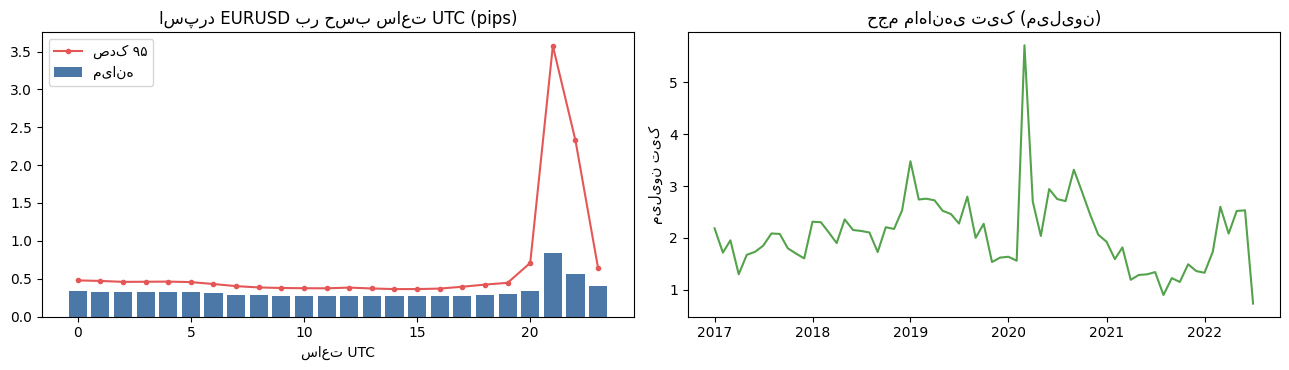

,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
میانه (pips),0.339,0.330,0.320,0.321,0.323,0.320,0.306,0.287,0.278,0.277,...,0.267,0.266,0.269,0.276,0.283,0.292,0.336,0.843,0.564,0.400
صدک ۹۵,0.477,0.470,0.458,0.459,0.461,0.455,0.429,0.401,0.384,0.377,...,0.362,0.363,0.369,0.393,0.422,0.445,0.708,3.575,2.325,0.638
میانگین,0.362,0.353,0.337,0.340,0.339,0.337,0.322,0.309,0.287,0.283,...,0.275,0.275,0.279,0.290,0.303,0.321,0.400,1.219,0.846,0.442


In [4]:
# ==================================================================================
# Cell 2 — کنترل کیفیت داده (QA): تراکم تیک، اسپرد، شکاف‌ها و جهش‌های ناگهانی
# ==================================================================================
import matplotlib.pyplot as plt

_t = time.time()
_ts_all = np.asarray(TS)
_d = np.diff(_ts_all)
_big = np.where(_d > 30 * 60_000)[0]
gap_tbl = pd.DataFrame({
    "شروع (UTC)": pd.to_datetime(_ts_all[_big], unit="ms"),
    "پایان (UTC)": pd.to_datetime(_ts_all[_big + 1], unit="ms"),
    "مدت (ساعت)": (_d[_big] / 3.6e6).round(1)}).sort_values("مدت (ساعت)", ascending=False)
print(f"شکاف‌های بیش از ۳۰ دقیقه: {len(_big)} مورد (بیشتر تعطیلات آخر هفته/کریسمس/سال نو)")
display(gap_tbl.head(8).reset_index(drop=True))

# M1 از تیک‌ها (یک بار، کل بازه)
M1 = build_m1_frame(TS, BID, ASK)
print(f"دقیقه‌های دارای تیک: {len(M1):,} | زمان ساخت M1: {time.time() - _t:.1f}s")

_hr = M1.index.hour
spread_by_hour = M1.groupby(_hr)["spread"].agg(["median", lambda s: s.quantile(0.95), "mean"])
spread_by_hour.columns = ["میانه (pips)", "صدک ۹۵", "میانگین"]
_yr_ticks = M1.groupby(M1.index.year)["ticks"].sum()
_yr_tph = (M1.groupby(M1.index.year)["ticks"].sum() / M1.groupby(M1.index.year).size()).round(0)
qa_year = pd.DataFrame({"تیک (میلیون)": (_yr_ticks / 1e6).round(2), "میانگین تیک در دقیقه‌ی فعال": _yr_tph})
display(qa_year)
print("توجه: تراکم تیک در سال ۲۰۲۱ حدود نصف ۲۰۲۰ است؛ این تغییر ساختاری داده است و در گزارش نهایی به آن اشاره می‌شود.")

fig, ax = plt.subplots(1, 2, figsize=(13, 3.8))
ax[0].bar(spread_by_hour.index, spread_by_hour["میانه (pips)"], color="#4C78A8", label="میانه")
ax[0].plot(spread_by_hour.index, spread_by_hour["صدک ۹۵"], color="#E45756", marker="o", ms=3, label="صدک ۹۵")
ax[0].set_title("اسپرد EURUSD بر حسب ساعت UTC (pips)"); ax[0].set_xlabel("ساعت UTC"); ax[0].legend()
_m = M1["ticks"].resample("MS").sum()
ax[1].plot(_m.index, _m.values / 1e6, color="#54A24B")
ax[1].set_title("حجم ماهانه‌ی تیک (میلیون)"); ax[1].set_ylabel("میلیون تیک")
plt.tight_layout(); plt.show()
display(spread_by_hour.round(3).T)

## ۴. پروتکل ارزیابی (بدون نگاه به آینده و بدون تنظیم روی holdout)
| بخش | بازه | کاربرد |
|---|---|---|
| **پژوهش** | ۲۰۱۷-۰۱ تا ۲۰۲۰-۱۲ | توسعه‌ی قاعده‌ها و آموزش ML؛ **walk-forward** با ۱۲ فصل آزمون خارج از نمونه (۲۰۱۸Q1–۲۰۲۰Q4) |
| **holdout (گاوصندوق)** | ۲۰۲۱-۰۱ تا ۲۰۲۲-۰۶ | فقط یک‌بار، با پیکربندی منجمد (قاعده‌ها) یا بازآموزی فصلی با داده‌ی قبلی (ML) |
| **embargo** | ۱ روز | بین آموزش و آزمون؛ برچسب‌های هر نمونه‌ی آموزش باید قبل از شروع فصل آزمون (منهای embargo) تمام شده باشند |

**قواعد کلیدی:**
- در هر فصل، پارامترها فقط با داده‌ی **قبل از همان فصل** انتخاب می‌شوند (معیار: t-stat میانگین R معاملات آموزش، حداقل ۴۰ معامله).
- **کلید خاموشی:** اگر بهترین t-stat آموزش منفی باشد، آن فصل معامله نمی‌شود (در غیر این صورت سیستم بهترین زیان‌ده را انتخاب می‌کند).
- آستانه‌ی احتمال ML با صدک‌ها روی 25٪ انتهایی داده‌ی آموزش انتخاب می‌شود (اعتبارسنجی درون‌نمونه‌ای).
- **شفافیت:** نتایج holdout برای همه‌ی روش‌ها نشان داده شده‌اند، اما انتخاب استراتژی فقط با داده‌ی پژوهش انجام شده است.

In [5]:
# ==================================================================================
# Cell 3 — پروتکل ارزیابی و توابع کمکی (بدون نگاه به آینده)
# ==================================================================================
from itertools import combinations
from scipy.stats import norm, skew, kurtosis

EMBARGO_MS = MS_DAY  # فاصله‌ی احتیاطی بین آموزش و آزمون (و افق برچسب‌ها)


def ms(x):
    return int(pd.Timestamp(x).value // 10 ** 6)


def quarters(start, end):
    q = pd.date_range(start, end, freq="QS")
    return [(ms(a), ms(b), f"{a.year}Q{a.quarter}") for a, b in zip(q[:-1], q[1:])]


RP_START, RP_END = ms("2017-01-01"), ms("2021-01-01")   # پژوهش: توسعه و walk-forward
HO_START, HO_END = ms("2021-01-01"), ms("2022-07-01")   # گاوصندوق (holdout): یک‌بار، با پیکربندی منجمد؛ 2022-07 ناقص است و کنار گذاشته می‌شود
OOS_Q = quarters("2018-01-01", "2021-01-01")            # 12 فصل آزمون خارج از نمونه (walk-forward)
HO_Q = quarters("2021-01-01", "2022-07-01")             # 6 فصل holdout

PRM0 = default_params(equity=10_000.0, risk=0.005, max_lev=30.0, comm=3.5, slip_pips=0.1,
                      latency_ms=1000, fillwin_ms=30_000, max_spread_pips=2.0)
TRC = ["entry_ts", "exit_ts", "dir", "entry", "exit", "lots", "gross", "comm", "net", "reason",
       "risk", "sl", "tp", "mae", "mfe", "spread_in", "sig", "hold_min"]


def run_window(cands, t0, t1, prm=None, eq0=None):
    """اجرای موتور تیک‌به‌تیک روی بازه‌ی [t0, t1). پوزیشن‌های باز در t1 با آخرین تیک بسته می‌شوند."""
    prm = PRM0.copy() if prm is None else prm.copy()
    if eq0 is not None:
        prm[P_EQ0] = eq0
    i0 = int(np.searchsorted(TS, t0, side="left"))
    i1 = int(np.searchsorted(TS, t1, side="left"))
    d = cands["dec_ms"].values
    c = cands[(d >= t0) & (d < t1)]
    tr, eq, bal, dda, ddr, ntr = run_engine(
        TS[i0:i1], BID[i0:i1], ASK[i0:i1],
        c["dec_ms"].values.astype(np.int64), c["dir"].values.astype(np.float64),
        c["sl"].values.astype(np.float64), c["tp"].values.astype(np.float64),
        c["hold"].values.astype(np.int64), prm)
    return {"tr": tr, "eq": eq, "bal": bal, "dd_abs": dda, "dd_rel": ddr, "n_sig": len(c), "eq0": prm[P_EQ0]}


def trades_frame(tr):
    df = pd.DataFrame(tr, columns=TRC)
    if len(df) == 0:
        return df
    df["entry_time"] = pd.to_datetime(df["entry_ts"].astype(np.int64), unit="ms")
    df["exit_time"] = pd.to_datetime(df["exit_ts"].astype(np.int64), unit="ms")
    df["R"] = df["net"] / df["risk"]
    df["net_pips"] = df["net"] / (df["lots"] * PIP_VALUE_LOT * 10.0)  # ۱ pip = ۱۰ دلار برای هر لات
    df["exit_reason"] = df["reason"].astype(int).map(EXIT_NAMES)
    return df


def equity_series(eq, eq0):
    s = pd.Series(eq[:, 1], index=pd.to_datetime(eq[:, 0].astype(np.int64), unit="ms")).sort_index()
    return s[~s.index.duplicated(keep="last")]


def monthly_returns(eq, eq0):
    s = equity_series(eq, eq0)
    if len(s) == 0:
        return pd.Series(dtype=float)
    eom = s.resample("ME").last().ffill().fillna(eq0)
    prev = np.concatenate([[eq0], eom.values[:-1]])
    return pd.Series(eom.values / prev - 1.0, index=eom.index.to_period("M"))


def daily_returns(eq, eq0):
    s = equity_series(eq, eq0)
    if len(s) == 0:
        return pd.Series(dtype=float)
    eod = s.resample("D").last().ffill().fillna(eq0)
    eod = eod[eod.index.dayofweek < 5]
    return eod.pct_change().dropna()


def summarize(tr, eq, eq0, dd_rel, dd_abs, t0, t1, label=""):
    df = trades_frame(tr)
    out = {"strategy": label, "trades": int(len(df))}
    years = (t1 - t0) / (365.25 * MS_DAY)
    end_eq = float(eq[-1, 1]) if len(eq) else eq0
    out["net_profit_%"] = 100 * (end_eq / eq0 - 1)
    out["CAGR_%"] = 100 * ((max(end_eq, 1e-9) / eq0) ** (1 / years) - 1) if years > 0 else np.nan
    mr = monthly_returns(eq, eq0)
    out["months"] = int(len(mr))
    out["monthly_mean_%"] = 100 * mr.mean() if len(mr) else np.nan
    out["monthly_median_%"] = 100 * mr.median() if len(mr) else np.nan
    out["monthly_min_%"] = 100 * mr.min() if len(mr) else np.nan
    out["monthly_max_%"] = 100 * mr.max() if len(mr) else np.nan
    out["months_>=3%_%"] = 100 * (mr >= 0.03).mean() if len(mr) else np.nan
    out["months_>0_%"] = 100 * (mr > 0).mean() if len(mr) else np.nan
    out["maxDD_%"] = 100 * dd_rel
    out["maxDD_usd"] = dd_abs
    out["Calmar"] = out["CAGR_%"] / out["maxDD_%"] if out["maxDD_%"] > 0 else np.nan
    dr = daily_returns(eq, eq0)
    out["Sharpe_daily_ann"] = dr.mean() / dr.std() * np.sqrt(252) if len(dr) > 2 and dr.std() > 0 else np.nan
    if len(df):
        R = df["R"].values
        out["win_rate_%"] = 100 * (R > 0).mean()
        out["avg_R"] = R.mean()
        out["t_stat_R"] = R.mean() / (R.std(ddof=1) / np.sqrt(len(R))) if len(R) > 1 and R.std() > 0 else np.nan
        gp = df.loc[df.net > 0, "net"].sum()
        gl = -df.loc[df.net < 0, "net"].sum()
        out["profit_factor"] = gp / gl if gl > 0 else np.nan
        out["avg_net_pips"] = df["net_pips"].mean()
        out["avg_hold_h"] = df["hold_min"].mean() / 60
        out["spread_cost_usd_est"] = float((df["spread_in"] * df["lots"] * CONTRACT).sum())
        out["commission_usd"] = float(df["comm"].sum())
    return out


def boot_ci(x, stat=np.mean, B=2000, seed=0, alpha=0.05):
    x = np.asarray(x, dtype=float)
    if len(x) < 3:
        return (np.nan, np.nan)
    rng = np.random.default_rng(seed)
    idx = rng.integers(0, len(x), size=(B, len(x)))
    v = stat(x[idx], axis=1)
    return float(np.quantile(v, alpha / 2)), float(np.quantile(v, 1 - alpha / 2))


def deflated_sharpe(sr_hat, T, skew_, kurt_, n_trials, var_trials):
    """Bailey & López de Prado (2014). sr_hat و var_trials بر حسب واحد دوره (غیرسالانه)."""
    emc = 0.5772156649
    sr0 = np.sqrt(max(var_trials, 1e-12)) * ((1 - emc) * norm.ppf(1 - 1 / n_trials) + emc * norm.ppf(1 - 1 / (n_trials * np.e)))
    denom = np.sqrt(max(1 - skew_ * sr_hat + (kurt_ - 1) / 4 * sr_hat ** 2, 1e-12))
    z = (sr_hat - sr0) * np.sqrt(max(T - 1, 1)) / denom
    return float(norm.cdf(z)), float(sr0)


def pbo_cscv(M, S=12):
    """Probability of Backtest Overfitting با CSCV (Bailey et al. 2015). M: دوره‌ها × استراتژی‌ها."""
    T, N = M.shape
    blocks = np.array_split(np.arange(T), S)
    logits = []
    for comb in combinations(range(S), S // 2):
        is_idx = np.concatenate([blocks[b] for b in comb])
        oos_idx = np.concatenate([blocks[b] for b in range(S) if b not in comb])
        p_is = M[is_idx].mean(axis=0)
        p_oos = M[oos_idx].mean(axis=0)
        n_star = int(np.argmax(p_is))
        rank = (p_oos < p_oos[n_star]).sum() + 0.5 * ((p_oos == p_oos[n_star]).sum() - 1) + 1
        w = rank / (N + 1)
        logits.append(np.log(w / (1 - w)))
    logits = np.array(logits)
    return float((logits <= 0).mean()), logits


def tstat(x):
    x = np.asarray(x, dtype=float)
    return float(x.mean() / (x.std(ddof=1) / np.sqrt(len(x)))) if len(x) > 2 and x.std(ddof=1) > 0 else -np.inf


print("پروتکل:")
print(f"  پژوهش (walk-forward): {pd.Timestamp(RP_START, unit='ms').date()} تا {pd.Timestamp(RP_END, unit='ms').date()} | {len(OOS_Q)} فصل آزمون")
print(f"  گاوصندوق (holdout):   {pd.Timestamp(HO_START, unit='ms').date()} تا {pd.Timestamp(HO_END, unit='ms').date()} | {len(HO_Q)} فصل")
print(f"  embargo: {EMBARGO_MS // MS_DAY} روز | ورودی: تیک بعد از تأخیر {PRM0[P_LAT]:.0f}ms | اسپرد بیشینه: {PRM0[P_MAXSPREAD] / PIP:.1f} pips")

پروتکل:
  پژوهش (walk-forward): 2017-01-01 تا 2021-01-01 | 12 فصل آزمون
  گاوصندوق (holdout):   2021-01-01 تا 2022-07-01 | 6 فصل
  embargo: 1 روز | ورودی: تیک بعد از تأخیر 1000ms | اسپرد بیشینه: 2.0 pips


## ۵. سیگنال‌های قانون‌محور (چهار خانواده)
- **F1 شکست رنج آسیا در باز شدن لندن (M5):** بالا/پایین بازه‌ی ۰۰:۰۰–۰۷:۰۰ UTC؛ اولین شکست بعد از ۰۷:۰۰ تا ۱۰ یا ۱۲ UTC؛ فیلتر اندازه‌ی رنج.
- **F2 شکست دونچیان H1 با فیلتر EMA200:** شکست بالای/پایین ۲۴ یا ۴۸ کندل قبلی، در جهت روند EMA200، SL = k·ATR، TP = rr·SL، سقف زمانی ۵ روز.
- **F3 بازگشت به میانگین (M15):** خارج شدن از باند بولینگر و RSI افراطی در رژیم کم‌ADX؛ هدف = میانگین.
- **F4 الگوی پیوت (M15، بازتعریف ساده‌شده‌ی ایده‌ی Pivot Settlement قبلی):** فراکتال علّی (تأیید بعد از ۳ کندل)، موج AB با حداقل ۲ یا ۳ برابر ATR، اصلاح به ۵۰–۷۸.۶٪ و بسته‌شدن برگشتی. این نسخه ترجمه‌ی مستقیم کد قبلی نیست.

In [6]:
# ==================================================================================
# Cell 4 — ساخت نوار (bar) و سیگنال‌های چهار خانواده‌ی قانون‌محور
# F1 شکست رنج آسیا در باز شدن لندن | F2 شکست دونچیان H1 با فیلتر EMA200
# F3 بازگشت به میانگین (بولینگر+RSI+ADX پایین) | F4 الگوی پیوت: AB + اصلاح 50–78.6% + بسته‌شدن برگشتی
# ==================================================================================
BARS = {}
BARS["m1"] = M1
BARS["b5"] = resample_bars(M1, "5min")
BARS["b15"] = resample_bars(M1, "15min")
BARS["b1"] = resample_bars(M1, "1h")
for _k in ["b5", "b15", "b1"]:
    print(f"{_k}: {len(BARS[_k]):,} نوار با تیک")

FAMILY_FN = {
    "F1_AsiaBreakout": ("b5", f1_asia_breakout),
    "F2_Donchian": ("b1", f2_donchian),
    "F3_MeanRev": ("b15", f3_mean_reversion),
    "F4_PivotRetrace": ("b15", f4_pivot_retrace),
}
GRID_CFG = {
    "F1_AsiaBreakout": [dict(sl_mode=m, rr=r, win_end_h=w, buf_pips=b)
                        for m in ["range", "atr"] for r in [1.0, 1.5, 2.0] for w in [10, 12] for b in [0.0, 1.0]],
    "F2_Donchian": [dict(n=n, k=k, rr=r) for n in [24, 48] for k in [1.5, 2.5] for r in [1.5, 3.0]],
    "F3_MeanRev": [dict(bb_k=b, sl_atr=s) for b in [2.0, 2.5] for s in [1.5, 2.5]],
    "F4_PivotRetrace": [dict(ab_atr=a, rr=r, max_wait=w) for a in [2.0, 3.0] for r in [1.0, 2.0] for w in [20, 40]],
}
N_RULE_CONFIGS = sum(len(v) for v in GRID_CFG.values())


def cfg_name(fam, cfg):
    return fam + "|" + ",".join(f"{k}={v}" for k, v in cfg.items())


def make_cands(fam, cfg):
    bkey, fn = FAMILY_FN[fam]
    return fn(BARS[bkey], **cfg)


CANDS = {}
_rows = []
for _fam, _grid in GRID_CFG.items():
    CANDS[_fam] = {}
    for _cfg in _grid:
        _name = cfg_name(_fam, _cfg)
        _c = make_cands(_fam, _cfg)
        CANDS[_fam][_name] = _c
        _rows.append({"family": _fam, "config": ",".join(f"{k}={v}" for k, v in _cfg.items()),
                      "signals": len(_c), "long_%": 100 * (_c["dir"] > 0).mean() if len(_c) else np.nan})
display(pd.DataFrame(_rows).groupby("family").agg(configs=("config", "size"), min_signals=("signals", "min"),
                                                   median_signals=("signals", "median"), max_signals=("signals", "max")))

b5: 410,601 نوار با تیک
b15: 136,879 نوار با تیک
b1: 34,223 نوار با تیک


,configs,min_signals,median_signals,max_signals
family,,,,
F1_AsiaBreakout,24,1102,1180.0,1233
F2_Donchian,8,1457,1644.5,1832
F3_MeanRev,4,785,936.0,1087
F4_PivotRetrace,8,1727,2143.5,2561


### خودآزمایی موتور
قبل از هر آزمایش، موتور روی یک ماه داده بررسی می‌شود: تطابق موجودی با مجموع سود، زمان ورود، سطح TP/SL، حجم لات و تک‌پوزیشن بودن. اگر یکی از این‌ها شکست بخورد، اجرای بعدی متوقف می‌شود.

In [7]:
# ==================================================================================
# خودآزمایی موتور (Unit checks) روی یک ماه داده — اگر یکی شکست بخورد، اجرای بعدی متوقف می‌شود
# ==================================================================================
_c_name = list(CANDS["F2_Donchian"].keys())[0]
_cd_full = CANDS["F2_Donchian"][_c_name]
_t0, _t1 = ms("2019-03-01"), ms("2019-04-01")
_res = run_window(_cd_full, _t0, _t1)
_tr = _res["tr"]
_cwin = _cd_full[(_cd_full["dec_ms"].values >= _t0) & (_cd_full["dec_ms"].values < _t1)].reset_index(drop=True)
_checks = {}
_checks["مانده = سرمایه‌ی اولیه + مجموع خالص سود معاملات"] = bool(
    abs(_res["bal"] - (PRM0[P_EQ0] + _tr[:, TR_NET].sum())) < 1e-6)
if len(_tr):
    _sig = _tr[:, TR_SIG].astype(int)
    _lag = _tr[:, TR_ENTRY_TS] - _cwin["dec_ms"].values[_sig]
    _checks["ورود حداقل پس از تأخیر تنظیم‌شده است"] = bool(np.all(_lag >= PRM0[P_LAT] - 1e-9))
    _d = _tr[:, TR_DIR]
    _sl_lvl = _tr[:, TR_ENTRY] - _d * _tr[:, TR_SL]
    _tp_m = _tr[:, TR_REASON] == 1
    _checks["خروج TP دقیقاً روی سطح TP پر می‌شود"] = bool(
        np.all(np.abs(_tr[_tp_m, TR_EXIT] - (_tr[_tp_m, TR_ENTRY] + _d[_tp_m] * _tr[_tp_m, TR_TP])) < 1e-9)) if _tp_m.any() else True
    _sl_m = _tr[:, TR_REASON] == 0
    _checks["خروج SL همیشه در سمت زیان نسبت به سطح SL است"] = bool(
        np.all(_d[_sl_m] * (_tr[_sl_m, TR_EXIT] - _sl_lvl[_sl_m]) <= 1e-12)) if _sl_m.any() else True
    _checks["حجم لات: ریسک واقعی ≤ ریسک هدف"] = bool(
        np.all(_tr[:, TR_LOTS] * _tr[:, TR_SL] * CONTRACT <= _tr[:, TR_RISK] * (1 + 1e-7)))
    _checks["حداکثر یک پوزیشن هم‌زمان (ورود بعد از خروج قبلی)"] = bool(
        np.all(_tr[1:, TR_ENTRY_TS] >= _tr[:-1, TR_EXIT_TS]))
    _checks["زمان خروج بعد از زمان ورود است"] = bool(np.all(_tr[:, TR_EXIT_TS] >= _tr[:, TR_ENTRY_TS]))
print(f"خودآزمایی روی «{_c_name}» در مارس ۲۰۱۹ | {len(_tr)} معامله")
for _k, _v in _checks.items():
    print(("✔" if _v else "✘"), _k)
assert all(_checks.values()), "خودآزمایی موتور ناموفق بود"
print("همه‌ی خودآزمایی‌ها گذشت.")

خودآزمایی روی «F2_Donchian|n=24,k=1.5,rr=1.5» در مارس ۲۰۱۹ | 16 معامله
✔ مانده = سرمایه‌ی اولیه + مجموع خالص سود معاملات
✔ ورود حداقل پس از تأخیر تنظیم‌شده است
✔ خروج TP دقیقاً روی سطح TP پر می‌شود
✔ خروج SL همیشه در سمت زیان نسبت به سطح SL است
✔ حجم لات: ریسک واقعی ≤ ریسک هدف
✔ حداکثر یک پوزیشن هم‌زمان (ورود بعد از خروج قبلی)
✔ زمان خروج بعد از زمان ورود است
همه‌ی خودآزمایی‌ها گذشت.


## ۶. Walk-forward خانواده‌های قانون‌محور
پیکربندی هر فصل فقط با داده‌ی گذشته انتخاب می‌شود. جدول زیر نتیجه‌ی ادغام فصل‌های خارج از نمونه (2018–2020) و holdout را نشان می‌دهد.

**تفسیر:** F1 و F2 در پژوهش زیان‌ده‌اند (F2 با ضریب سود ۰.۹۶ کمی زیان‌ده است). F3 و F4 توسط کلید خاموشی در همه‌ی فصل‌ها غیرفعال شدند، زیرا بهترین t-stat آموزش آن‌ها منفی بود. در holdout، F2 حدود −۷٪ است. اجرای «بی‌قید» F4 در holdout ۲۹٪ زیان می‌دهد؛ یعنی این الگو با هزینه‌ی واقعی سودآور نیست.

In [8]:
# ==================================================================================
# Cell 5 — Walk-forward برای خانواده‌های قانون‌محور
# • انتخاب پارامتر در هر فصل فقط با داده‌ی قبل از همان فصل (+embargo) و معیار t-stat میانگین R
# • ادامه‌ی سرمایه بین فصل‌ها؛ DD سراسری از رویدادهای سرمایه (دقت تیک‌به‌تیک در هر اجرای مجزا)
# • پیکربندی منجمد برای holdout فقط با داده‌ی پژوهش (2017–2020) انتخاب می‌شود
# ==================================================================================
MIN_TRAIN_TRADES = 40
MIN_TSTAT_TRADE = 0.0   # کلید خاموشی: اگر بهترین t-stat آموزش منفی باشد، در آن فصل معامله نمی‌شود


def dd_from_events(eq):
    if len(eq) == 0:
        return 0.0, 0.0
    v = eq[:, 1]
    pk = np.maximum.accumulate(v)
    return float(((pk - v) / pk).max()), float((pk - v).max())


def score_cfg(cd, t0, t1):
    r = run_window(cd, t0, t1)
    tr = r["tr"]
    if len(tr) < MIN_TRAIN_TRADES:
        return -np.inf, r
    R = tr[:, TR_NET] / tr[:, TR_RISK]
    return tstat(R), r


WFO = {}
PBO_COLS = {}
for fam, grid in GRID_CFG.items():
    cd_map = CANDS[fam]
    for name, cd in cd_map.items():  # برای PBO: اجرای ثابت هر پیکربندی روی 2018–2020
        r = run_window(cd, ms("2018-01-01"), RP_END)
        PBO_COLS[name] = monthly_returns(r["eq"], PRM0[P_EQ0])

    oos_tr, oos_eq, folds = [], [], []
    bal = PRM0[P_EQ0]
    for qs, qe, lab in OOS_Q:
        best_sc, best_name = -np.inf, None
        for name, cd in cd_map.items():
            sc, _ = score_cfg(cd, RP_START, qs - EMBARGO_MS)
            if sc > best_sc:
                best_sc, best_name = sc, name
        if best_name is None or best_sc < MIN_TSTAT_TRADE:
            folds.append({"فصل": lab, "پیکربندی انتخابی": "— (کلید خاموشی)", "t-stat آموزش": round(best_sc, 2),
                          "معامله‌ی OOS": 0, "بازده‌ی فصل %": 0.0})
            oos_eq.append(np.array([[qs, bal], [qe - 1, bal]]))
            continue
        r = run_window(cd_map[best_name], qs, qe, eq0=bal)
        if len(r["tr"]):
            oos_tr.append(r["tr"])
        oos_eq.append(r["eq"])
        bal_prev = bal
        bal = r["bal"]
        folds.append({"فصل": lab, "پیکربندی انتخابی": best_name.split("|")[1], "t-stat آموزش": round(best_sc, 2),
                      "معامله‌ی OOS": len(r["tr"]), "بازده‌ی فصل %": round(100 * (bal / bal_prev - 1), 2)})

    tr_all = np.vstack(oos_tr) if oos_tr else np.zeros((0, TR_NCOL))
    eq_all = np.vstack(oos_eq)
    ddr, dda = dd_from_events(eq_all)
    summ_oos = summarize(tr_all, eq_all, PRM0[P_EQ0], ddr, dda, ms("2018-01-01"), RP_END, label=fam + " (WF-OOS)")

    best_full, name_full = -np.inf, None
    for name, cd in cd_map.items():
        sc, _ = score_cfg(cd, RP_START, RP_END)
        if sc > best_full:
            best_full, name_full = sc, name
    r_ho = run_window(cd_map[name_full], HO_START, HO_END)  # اجرای بی‌قید (برای شفافیت)
    summ_ho = summarize(r_ho["tr"], r_ho["eq"], PRM0[P_EQ0], r_ho["dd_rel"], r_ho["dd_abs"], HO_START, HO_END,
                        label=fam + " (holdout، بی‌قید)")
    kill = best_full < MIN_TSTAT_TRADE  # طبق پروتکل: اگر t-stat پژوهش منفی است، این خانواده در holdout معامله نمی‌کند
    summ_ho_p = summarize(np.zeros((0, TR_NCOL)), np.array([[HO_START, PRM0[P_EQ0]], [HO_END - 1, PRM0[P_EQ0]]]),
                          PRM0[P_EQ0], 0.0, 0.0, HO_START, HO_END, label=fam + " (holdout، طبق پروتکل)") if kill else \
        summarize(r_ho["tr"], r_ho["eq"], PRM0[P_EQ0], r_ho["dd_rel"], r_ho["dd_abs"], HO_START, HO_END,
                  label=fam + " (holdout، طبق پروتکل)")
    WFO[fam] = dict(oos_summary=summ_oos, oos_tr=tr_all, oos_eq=eq_all, folds=pd.DataFrame(folds),
                    frozen=name_full, frozen_score=best_full, holdout=r_ho, holdout_summary=summ_ho,
                    holdout_protocol=summ_ho_p, killed_holdout=kill)
    print(f"\n=== {fam} | پیکربندی منجمد: {name_full.split('|')[1]} (t-stat پژوهش={best_full:.2f})")
    display(WFO[fam]["folds"])

RULE_SUMMARY = pd.DataFrame([WFO[f]["oos_summary"] for f in WFO] + [WFO[f]["holdout_protocol"] for f in WFO]
                            + [WFO[f]["holdout_summary"] for f in WFO])
_cols = ["strategy", "trades", "net_profit_%", "CAGR_%", "monthly_mean_%", "months_>=3%_%", "maxDD_%",
         "win_rate_%", "avg_R", "t_stat_R", "profit_factor", "Sharpe_daily_ann"]
display(RULE_SUMMARY[_cols].round(3).set_index("strategy"))


=== F1_AsiaBreakout | پیکربندی منجمد: sl_mode=range,rr=2.0,win_end_h=10,buf_pips=1.0 (t-stat پژوهش=-1.18)


,فصل,پیکربندی انتخابی,t-stat آموزش,معامله‌ی OOS,بازده‌ی فصل %
0,2018Q1,"sl_mode=range,rr=2.0,win_end_h=10,buf_pips=1.0",0.92,52,-0.83
1,2018Q2,"sl_mode=range,rr=2.0,win_end_h=10,buf_pips=1.0",0.72,60,-7.37
2,2018Q3,— (کلید خاموشی),-0.16,0,0.00
3,2018Q4,— (کلید خاموشی),-0.58,0,0.00
4,2019Q1,— (کلید خاموشی),-1.04,0,0.00
5,2019Q2,— (کلید خاموشی),-1.22,0,0.00
6,2019Q3,— (کلید خاموشی),-1.81,0,0.00
7,2019Q4,— (کلید خاموشی),-1.37,0,0.00
8,2020Q1,— (کلید خاموشی),-1.66,0,0.00
9,2020Q2,— (کلید خاموشی),-1.38,0,0.00



=== F2_Donchian | پیکربندی منجمد: n=24,k=2.5,rr=1.5 (t-stat پژوهش=0.27)


,فصل,پیکربندی انتخابی,t-stat آموزش,معامله‌ی OOS,بازده‌ی فصل %
0,2018Q1,"n=24,k=1.5,rr=1.5",0.74,64,2.48
1,2018Q2,"n=48,k=1.5,rr=1.5",1.10,47,0.58
2,2018Q3,"n=48,k=1.5,rr=1.5",1.07,49,2.17
3,2018Q4,"n=48,k=1.5,rr=1.5",1.20,44,-4.49
4,2019Q1,"n=48,k=1.5,rr=1.5",0.73,43,-1.94
5,2019Q2,"n=48,k=1.5,rr=1.5",0.53,42,0.09
6,2019Q3,"n=48,k=1.5,rr=1.5",0.51,42,1.81
7,2019Q4,"n=48,k=1.5,rr=1.5",0.63,45,-1.79
8,2020Q1,"n=48,k=2.5,rr=1.5",0.68,39,4.41
9,2020Q2,"n=48,k=2.5,rr=1.5",1.07,43,-6.33



=== F3_MeanRev | پیکربندی منجمد: bb_k=2.5,sl_atr=1.5 (t-stat پژوهش=-3.64)


,فصل,پیکربندی انتخابی,t-stat آموزش,معامله‌ی OOS,بازده‌ی فصل %
0,2018Q1,— (کلید خاموشی),-1.43,0,0.0
1,2018Q2,— (کلید خاموشی),-1.64,0,0.0
2,2018Q3,— (کلید خاموشی),-2.56,0,0.0
3,2018Q4,— (کلید خاموشی),-3.34,0,0.0
4,2019Q1,— (کلید خاموشی),-3.41,0,0.0
5,2019Q2,— (کلید خاموشی),-3.01,0,0.0
6,2019Q3,— (کلید خاموشی),-2.95,0,0.0
7,2019Q4,— (کلید خاموشی),-3.09,0,0.0
8,2020Q1,— (کلید خاموشی),-3.31,0,0.0
9,2020Q2,— (کلید خاموشی),-3.60,0,0.0



=== F4_PivotRetrace | پیکربندی منجمد: ab_atr=3.0,rr=1.0,max_wait=40 (t-stat پژوهش=-7.02)


,فصل,پیکربندی انتخابی,t-stat آموزش,معامله‌ی OOS,بازده‌ی فصل %
0,2018Q1,— (کلید خاموشی),-3.80,0,0.0
1,2018Q2,— (کلید خاموشی),-4.11,0,0.0
2,2018Q3,— (کلید خاموشی),-4.05,0,0.0
3,2018Q4,— (کلید خاموشی),-4.74,0,0.0
4,2019Q1,— (کلید خاموشی),-4.47,0,0.0
5,2019Q2,— (کلید خاموشی),-4.83,0,0.0
6,2019Q3,— (کلید خاموشی),-5.13,0,0.0
7,2019Q4,— (کلید خاموشی),-5.96,0,0.0
8,2020Q1,— (کلید خاموشی),-6.46,0,0.0
9,2020Q2,— (کلید خاموشی),-6.33,0,0.0


,trades,net_profit_%,CAGR_%,monthly_mean_%,months_>=3%_%,maxDD_%,win_rate_%,avg_R,t_stat_R,profit_factor,Sharpe_daily_ann
strategy,,,,,,,,,,,
F1_AsiaBreakout (WF-OOS),112,-8.136,-2.789,-0.231,0.0,11.513,44.643,-0.149,-1.696,0.696,-0.955
F2_Donchian (WF-OOS),550,-5.844,-1.987,-0.150,0.0,11.951,41.273,-0.019,-0.386,0.961,-0.217
F3_MeanRev (WF-OOS),0,0.000,0.000,0.000,0.0,0.000,NaN,NaN,NaN,NaN,NaN
F4_PivotRetrace (WF-OOS),0,0.000,0.000,0.000,0.0,0.000,NaN,NaN,NaN,NaN,NaN
F1_AsiaBreakout (holdout، طبق پروتکل),0,0.000,0.000,0.000,0.0,0.000,NaN,NaN,NaN,NaN,NaN
F2_Donchian (holdout، طبق پروتکل),250,-6.958,-4.710,-0.386,0.0,11.035,42.800,-0.055,-0.801,0.894,-0.596
F3_MeanRev (holdout، طبق پروتکل),0,0.000,0.000,0.000,0.0,0.000,NaN,NaN,NaN,NaN,NaN
F4_PivotRetrace (holdout، طبق پروتکل),0,0.000,0.000,0.000,0.0,0.000,NaN,NaN,NaN,NaN,NaN
F1_AsiaBreakout (holdout، بی‌قید),313,-5.005,-3.376,-0.270,0.0,12.487,46.326,-0.031,-0.575,0.923,-0.487


## ۷. یادگیری ماشین: ویژگی‌ها و برچسب‌های سه‌مانعه‌ای از مسیر تیک
- **ویژگی‌ها (۲۶ ستون، کاملاً علّی):** بازده‌های نرمال‌شده با ATR در چند افق، RSI، ADX، موقعیت بولینگر و EMAها، موقعیت در کانال دونچیان ۴۸، ساعت (سینوسی)، روز هفته، اسپرد و نسبت به میانه‌ی ۲۴ ساعته، شدت تیک‌ها، سهم حرکت‌های صعودی تیک‌ها، زمینه‌ی روز قبل (بالا/پایین)، و روند H1 (با `merge_asof` علّی).
- **برچسب M2 (سه‌مانعه):** برای هر نوار M15 دو نامزد: خرید و فروش؛ SL = ۱·ATR، TP = ۱.۵·ATR، سقف زمانی ۴ ساعت. نتیجه با **مسیر تیک واقعی** و با هزینه‌ی کامل سنجیده می‌شود: برد اگر R خالص > 0.
- **برچسب M1 (متا-برچسب):** سیگنال‌های پایه‌ی چهار خانواده (پیکربندی میانی) را می‌گیرد و برچسب آن‌ها برد/باخت خالص همان معامله است. مدل فقط تشخیص می‌دهد کدام سیگنال‌ها ارزش اجرا دارند.
- **مدل:** `HistGradientBoostingClassifier` (جداگانه برای خرید و فروش در M2).

In [9]:
# ==================================================================================
# Cell 6 — ML: ویژگی‌های علّی (M15 + H1 + زمینه‌ی روز قبل) و برچسب‌های سه‌مانعه‌ای با مسیر تیک
#   M2 (مستقیم): هر نوار M15 دو نامزد (خرید/فروش) با SL=1·ATR، TP=1.5·ATR، سقف زمانی 4 ساعت
#   M1 (متا-برچسب): هر سیگنال خانواده‌های قانون‌محور، برچسب = برد/باخت خالص (با هزینه) همان معامله
# ==================================================================================
from sklearn.ensemble import HistGradientBoostingClassifier


def build_features(b15, b1):
    A = atr(b15)
    c = b15["close"]
    F = pd.DataFrame(index=b15.index)
    for k in [1, 4, 16, 64]:
        F[f"ret{k}"] = (c - c.shift(k)) / A
    F["atr_pips"] = A / PIP
    F["atr_ratio"] = A / A.rolling(96).mean()
    F["rsi14"] = rsi(c)
    F["adx14"] = adx(b15)
    m20 = c.rolling(20).mean()
    s20 = c.rolling(20).std()
    F["bbz20"] = (c - m20) / s20
    for n in [20, 50, 200]:
        F[f"ema{n}_d"] = (c - c.ewm(span=n, adjust=False).mean()) / A
    hi48 = b15["high"].rolling(48).max()
    lo48 = b15["low"].rolling(48).min()
    F["don48_pos"] = (c - lo48) / (hi48 - lo48)
    F["range_atr"] = (b15["high"] - b15["low"]) / A
    hr = b15.index.hour + b15.index.minute / 60.0
    F["hsin"] = np.sin(2 * np.pi * hr / 24)
    F["hcos"] = np.cos(2 * np.pi * hr / 24)
    F["dow"] = b15.index.dayofweek
    F["spread_pips"] = b15["spread"]
    F["spread_rel"] = b15["spread"] / b15["spread"].rolling(96).median()
    lt = np.log1p(b15["ticks"].astype(float))
    F["tick_rel"] = lt - lt.rolling(96).mean()
    F["upfrac"] = b15["up"] / (b15["up"] + b15["dn"]).replace(0, np.nan)
    F["upfrac4"] = b15["up"].rolling(4).sum() / (b15["up"] + b15["dn"]).rolling(4).sum()
    day = b15.index.normalize()
    dd = pd.DataFrame({"h": b15["high"].values, "l": b15["low"].values}, index=day).groupby(level=0).agg(h=("h", "max"), l=("l", "min"))
    F["pd_hi_d"] = (c.values - dd["h"].shift(1).reindex(day).values) / A.values
    F["pd_lo_d"] = (c.values - dd["l"].shift(1).reindex(day).values) / A.values
    A1 = atr(b1)
    c1 = b1["close"]
    H = pd.DataFrame({"dec_ms": b1["dec_ms"].values,
                      "h1_trend": ((c1.ewm(span=50, adjust=False).mean() - c1.ewm(span=200, adjust=False).mean()) / A1).values,
                      "h1_ret6": ((c1 - c1.shift(6)) / A1).values}).sort_values("dec_ms")
    F = F.reset_index(drop=True)
    F["dec_ms"] = b15["dec_ms"].values
    F = pd.merge_asof(F.sort_values("dec_ms"), H, on="dec_ms", direction="backward")  # علّی: H1 بسته‌شده قبل از همین لحظه
    return F


F15 = build_features(BARS["b15"], BARS["b1"])
FEAT_COLS = [c for c in F15.columns if c != "dec_ms"]
print(f"ویژگی‌ها: {len(FEAT_COLS)} ستون | نمونه‌ی نوار: {len(F15):,}")


def label_candidates(cd, prm=PRM0):
    o = candidate_outcomes(TS, BID, ASK, cd["dec_ms"].values.astype(np.int64), cd["dir"].values.astype(np.float64),
                           cd["sl"].values.astype(np.float64), cd["tp"].values.astype(np.float64),
                           cd["hold"].values.astype(np.int64), prm)
    out = cd.copy().reset_index(drop=True)
    out["filled"] = o[:, 0] == 1
    out["exit_ms"] = o[:, 3]
    out["reason"] = o[:, 4]
    out["net_pips"] = o[:, 5]
    out["R"] = o[:, 6]
    return out[out["filled"]].reset_index(drop=True)


# ---------- M2: نامزدهای مستقیم روی هر نوار M15 ----------
_b15 = BARS["b15"]
_A15 = atr(_b15).values
_base = pd.DataFrame({"dec_ms": _b15["dec_ms"].values, "sl": 1.0 * _A15, "tp": 1.5 * _A15,
                      "hold": np.full(len(_b15), 16 * 15 * MS_MIN, dtype=np.int64)})
_valid = F15[FEAT_COLS].notna().all(axis=1).values & np.isfinite(_A15) & (_A15 > 0)
_base = _base[_valid].reset_index(drop=True)
_parts = []
for _side in (1, -1):
    _cd = _base.copy()
    _cd["dir"] = float(_side)
    _lab = label_candidates(_cd)
    _lab["side"] = _side
    _parts.append(_lab)
M2S = pd.concat(_parts).sort_values(["dec_ms", "side"]).reset_index(drop=True)
M2S = M2S.merge(F15, on="dec_ms", how="left")
M2S["y"] = (M2S["R"] > 0).astype(int)
M2S["rid"] = np.arange(len(M2S))
print(f"M2: {len(M2S):,} نامزد پرشده | نرخ برد پایه = {100 * M2S['y'].mean():.1f}% | میانگین R = {M2S['R'].mean():.3f}")

# ---------- M1: متا-برچسب روی سیگنال‌های پایه‌ی هر چهار خانواده ----------
PRIMARY = {
    "F1_AsiaBreakout": dict(sl_mode="range", rr=1.5, win_end_h=10, buf_pips=0.0),
    "F2_Donchian": dict(n=48, k=2.0, rr=2.0),
    "F3_MeanRev": dict(bb_k=2.0, sl_atr=1.5),
    "F4_PivotRetrace": dict(ab_atr=2.0, rr=1.5, max_wait=40),
}
_pf = []
for _code, (_fam, _cfg) in enumerate(PRIMARY.items()):
    _cd = make_cands(_fam, _cfg).copy()
    _cd["fam"] = _code
    _pf.append(_cd)
PRIM = pd.concat(_pf).sort_values("dec_ms", kind="stable").reset_index(drop=True)
M1S = label_candidates(PRIM)
M1S = pd.merge_asof(M1S.sort_values("dec_ms"), F15.sort_values("dec_ms"), on="dec_ms", direction="backward")
M1S = M1S.dropna(subset=FEAT_COLS).reset_index(drop=True)
M1S["y"] = (M1S["R"] > 0).astype(int)
M1S["sl_pips"] = M1S["sl"] / PIP
M1S["tp_sl"] = M1S["tp"] / M1S["sl"]
M1S["rid"] = np.arange(len(M1S))
M1_FEATS = FEAT_COLS + ["fam", "sl_pips", "tp_sl", "dir"]
print(f"M1: {len(M1S):,} سیگنال پایه‌ی برچسب‌خورده | نرخ برد = {100 * M1S['y'].mean():.1f}% | میانگین R = {M1S['R'].mean():.3f}")

ویژگی‌ها: 26 ستون | نمونه‌ی نوار: 136,879
M2: 261,334 نامزد پرشده | نرخ برد پایه = 37.3% | میانگین R = -0.240
M1: 6,103 سیگنال پایه‌ی برچسب‌خورده | نرخ برد = 38.3% | میانگین R = -0.152


## ۸. Walk-forward ML، کنترل جایگشت و holdout با بازآموزی فصلی
- **کنترل جایگشت:** همان خط لوله با برچسب‌های آموزش به‌صورت تصادفی جابه‌جا می‌شود. اگر خط لوله حقیقتاً اطلاعات داشته باشد، نتیجه‌ی جایگشت‌یافته باید بدتر از نتیجه‌ی واقعی باشد.
- **تفسیر:** M2 در پژوهش و holdout زیان‌ده است و نتیجه‌ی جایگشت‌یافته حتی بدتر است؛ یعنی مدل اطلاعات نسبی دارد (نسبت به انتخاب تصادفی بهتر است)، اما این اطلاعات کوچک‌تر از هزینه‌ی اجرا است. M1 در پژوهش نزدیک صفر (+۰.۹٪) و در holdout مثبت (+۴.۸٪) است، ولی هنوز از نظر آماری معنادار نیست. آزمون جهت تصادفی در سلول نهایی این موضوع را بیشتر بررسی می‌کند.

In [10]:
# ==================================================================================
# Cell 7 — Walk-forward برای مدل‌های ML + آزمون جایگشت + holdout با بازآموزی فصلی (expanding)
# • آستانه‌ی احتمال (به‌صورت صدک) فقط روی 25% انتهایی داده‌ی آموزش (پیش از فصل آزمون) انتخاب می‌شود
# • هر فصل آزمون با مدلی آموزش می‌بیند که هیچ برچسبی از آینده (exit پس از فصل) در آن نیست
# ==================================================================================
def fit_hgb(X, y, seed=0):
    m = HistGradientBoostingClassifier(max_iter=150, learning_rate=0.05, max_leaf_nodes=31,
                                       min_samples_leaf=200, l2_regularization=1.0, random_state=seed)
    return m.fit(X, y)


QGRID = (0.80, 0.85, 0.90, 0.95, 0.97, 0.99)


def select_thr(p, R, min_n=100):
    best = None
    for q in QGRID:
        thr = np.quantile(p, q)
        m = p >= thr
        if m.sum() < min_n:
            continue
        mr = R[m].mean()
        if best is None or mr > best[1]:
            best = (q, mr, thr)
    return best


def ml_wfo(S, feats, quarters, seed=0, shuffle=False, max_train=100_000):
    rng = np.random.default_rng(seed)
    X = S[feats].values.astype(np.float64)
    dec = S["dec_ms"].values
    ex = S["exit_ms"].values.astype(np.float64)
    y = S["y"].values.astype(int)
    R = S["R"].values
    out, log = [], []
    for qs, qe, lab in quarters:
        train_end = qs - EMBARGO_MS
        tr_idx = np.where((ex < train_end) & (dec >= RP_START))[0]
        te_idx = np.where((dec >= qs) & (dec < qe))[0]
        if len(tr_idx) < 3000 or len(te_idx) == 0:
            continue
        y_w = y.copy()
        if shuffle:  # جایگشت برچسب‌های آموزش (آزمون صفر)
            y_w[tr_idx] = rng.permutation(y[tr_idx])
        t_tr = dec[tr_idx].astype(np.float64)
        cut = t_tr[0] + 0.75 * (t_tr[-1] - t_tr[0])
        a_idx = tr_idx[t_tr < cut - EMBARGO_MS]
        v_idx = tr_idx[t_tr >= cut]
        a_sub = a_idx if len(a_idx) <= max_train else np.sort(rng.choice(a_idx, max_train, replace=False))
        mA = fit_hgb(X[a_sub], y_w[a_sub], seed)
        pv = mA.predict_proba(X[v_idx])[:, 1]
        sel = select_thr(pv, R[v_idx])
        thr = sel[2] if sel else np.inf
        f_sub = tr_idx if len(tr_idx) <= max_train else np.sort(rng.choice(tr_idx, max_train, replace=False))
        mB = fit_hgb(X[f_sub], y_w[f_sub], seed)
        pt = mB.predict_proba(X[te_idx])[:, 1]
        out.append(pd.DataFrame({"rid": S["rid"].values[te_idx], "dec_ms": dec[te_idx], "p": pt,
                                 "thr": thr, "quarter": lab}))
        log.append({"فصل": lab, "نمونه‌ی آموزش": len(tr_idx), "صدک انتخابی": sel[0] if sel else np.nan,
                    "آستانه‌ی p": round(float(thr), 4) if sel else np.nan,
                    "میانگین R آموزش‌-اعتبارسنجی (انتخابی)": round(float(sel[1]), 3) if sel else np.nan})
    pred = pd.concat(out, ignore_index=True) if out else pd.DataFrame(columns=["rid", "dec_ms", "p", "thr", "quarter"])
    return pred, pd.DataFrame(log)


def signals_m1(pred):
    sel = pred[pred["p"].values >= pred["thr"].values]
    rows = M1S.set_index("rid").loc[sel["rid"].values]
    return rows.reset_index()[["dec_ms", "dir", "sl", "tp", "hold"]].sort_values("dec_ms").reset_index(drop=True)


def signals_m2(pred_L, pred_S):
    L = pred_L.set_index("dec_ms")[["p", "thr"]].rename(columns={"p": "pl", "thr": "tl"})
    Sh = pred_S.set_index("dec_ms")[["p", "thr"]].rename(columns={"p": "ps", "thr": "ts"})
    J = L.join(Sh, how="inner")
    lm = (J["pl"] >= J["tl"]) & (J["pl"] >= J["ps"])
    sm = (J["ps"] >= J["ts"]) & (J["ps"] > J["pl"])
    base = _base.set_index("dec_ms")
    lc = base.loc[J.index[lm.values]].reset_index()
    lc["dir"] = 1.0
    scd = base.loc[J.index[sm.values]].reset_index()
    scd["dir"] = -1.0
    return pd.concat([lc, scd]).sort_values("dec_ms").reset_index(drop=True)[["dec_ms", "dir", "sl", "tp", "hold"]]


ML_RES = {}
_S_L = M2S[M2S["side"] == 1].reset_index(drop=True)
_S_S = M2S[M2S["side"] == -1].reset_index(drop=True)
t_start = time.time()

# --- M2 (مستقیم): پیش‌بینی جدا برای خرید و فروش ---
pL_rs, logL = ml_wfo(_S_L, FEAT_COLS, OOS_Q, seed=0)
pS_rs, logS = ml_wfo(_S_S, FEAT_COLS, OOS_Q, seed=0)
sig_m2_rs = signals_m2(pL_rs, pS_rs)
r_m2_rs = run_window(sig_m2_rs, ms("2018-01-01"), RP_END)
ML_RES["M2_direct"] = dict(research=summarize(r_m2_rs["tr"], r_m2_rs["eq"], PRM0[P_EQ0], r_m2_rs["dd_rel"],
                                              r_m2_rs["dd_abs"], ms("2018-01-01"), RP_END, "M2 مستقیم (WF-OOS)"),
                           trades_rs=r_m2_rs["tr"], eq_rs=r_m2_rs["eq"])
print(f"M2 پژوهش در {time.time() - t_start:.0f}s | سیگنال‌ها: {len(sig_m2_rs):,}")
display(logL.assign(جهت="خرید").pipe(lambda d: pd.concat([d, logS.assign(جهت="فروش")])).reset_index(drop=True))

# --- M1 (متا-برچسب روی سیگنال‌های خانواده‌ها) ---
pM1_rs, logM1 = ml_wfo(M1S, M1_FEATS, OOS_Q, seed=0)
sig_m1_rs = signals_m1(pM1_rs)
r_m1_rs = run_window(sig_m1_rs, ms("2018-01-01"), RP_END)
ML_RES["M1_meta"] = dict(research=summarize(r_m1_rs["tr"], r_m1_rs["eq"], PRM0[P_EQ0], r_m1_rs["dd_rel"],
                                            r_m1_rs["dd_abs"], ms("2018-01-01"), RP_END, "M1 متا-برچسب (WF-OOS)"),
                         trades_rs=r_m1_rs["tr"], eq_rs=r_m1_rs["eq"])
print(f"M1 پژوهش در {time.time() - t_start:.0f}s | سیگنال‌ها: {len(sig_m1_rs):,}")
display(logM1)

# --- آزمون جایگشت: همان خط لوله با برچسب‌های آموزش جایگشت‌یافته ---
pL_p, _ = ml_wfo(_S_L, FEAT_COLS, OOS_Q, seed=1, shuffle=True)
pS_p, _ = ml_wfo(_S_S, FEAT_COLS, OOS_Q, seed=1, shuffle=True)
r_perm = run_window(signals_m2(pL_p, pS_p), ms("2018-01-01"), RP_END)
ML_RES["M2_permuted_null"] = dict(research=summarize(r_perm["tr"], r_perm["eq"], PRM0[P_EQ0], r_perm["dd_rel"],
                                                     r_perm["dd_abs"], ms("2018-01-01"), RP_END, "M2 جایگشت‌یافته (صفر)"))
pM1_p, _ = ml_wfo(M1S, M1_FEATS, OOS_Q, seed=1, shuffle=True)
r_perm1 = run_window(signals_m1(pM1_p), ms("2018-01-01"), RP_END)
ML_RES["M1_permuted_null"] = dict(research=summarize(r_perm1["tr"], r_perm1["eq"], PRM0[P_EQ0], r_perm1["dd_rel"],
                                                     r_perm1["dd_abs"], ms("2018-01-01"), RP_END, "M1 جایگشت‌یافته (صفر)"))
print(f"جایگشت در {time.time() - t_start:.0f}s")

# --- holdout: بازآموزی فصلی با داده‌ی کاملاً پیش از هر فصل ---
pL_ho, logL_ho = ml_wfo(_S_L, FEAT_COLS, HO_Q, seed=0)
pS_ho, logS_ho = ml_wfo(_S_S, FEAT_COLS, HO_Q, seed=0)
sig_m2_ho = signals_m2(pL_ho, pS_ho)
r_m2_ho = run_window(sig_m2_ho, HO_START, HO_END)
ML_RES["M2_direct"]["holdout"] = summarize(r_m2_ho["tr"], r_m2_ho["eq"], PRM0[P_EQ0], r_m2_ho["dd_rel"],
                                           r_m2_ho["dd_abs"], HO_START, HO_END, "M2 مستقیم (holdout)")
ML_RES["M2_direct"]["holdout_run"] = r_m2_ho
ML_RES["M2_direct"]["sig_ho"] = sig_m2_ho

pM1_ho, logM1_ho = ml_wfo(M1S, M1_FEATS, HO_Q, seed=0)
sig_m1_ho = signals_m1(pM1_ho)
r_m1_ho = run_window(sig_m1_ho, HO_START, HO_END)
ML_RES["M1_meta"]["holdout"] = summarize(r_m1_ho["tr"], r_m1_ho["eq"], PRM0[P_EQ0], r_m1_ho["dd_rel"],
                                         r_m1_ho["dd_abs"], HO_START, HO_END, "M1 متا-برچسب (holdout)")
ML_RES["M1_meta"]["holdout_run"] = r_m1_ho
ML_RES["M1_meta"]["sig_ho"] = sig_m1_ho
print(f"holdout در {time.time() - t_start:.0f}s")

ML_SUMMARY = pd.DataFrame([ML_RES["M2_direct"]["research"], ML_RES["M1_meta"]["research"],
                           ML_RES["M2_permuted_null"]["research"], ML_RES["M1_permuted_null"]["research"],
                           ML_RES["M2_direct"]["holdout"],
                           ML_RES["M1_meta"]["holdout"]])
display(ML_SUMMARY[["strategy", "trades", "net_profit_%", "CAGR_%", "monthly_mean_%", "months_>=3%_%",
                    "maxDD_%", "win_rate_%", "avg_R", "t_stat_R", "profit_factor"]].round(3).set_index("strategy"))

M2 پژوهش در 160s | سیگنال‌ها: 6,856


,فصل,نمونه‌ی آموزش,صدک انتخابی,آستانه‌ی p,میانگین R آموزش‌-اعتبارسنجی (انتخابی),جهت
0,2018Q1,23829,0.95,0.5881,-0.021,خرید
1,2018Q2,29751,0.80,0.4856,-0.077,خرید
2,2018Q3,35752,0.90,0.5183,-0.069,خرید
3,2018Q4,41744,0.97,0.5802,-0.003,خرید
4,2019Q1,47634,0.97,0.5670,-0.022,خرید
5,2019Q2,53538,0.99,0.6077,0.141,خرید
6,2019Q3,59543,0.99,0.5841,-0.037,خرید
7,2019Q4,65535,0.99,0.5672,-0.087,خرید
8,2020Q1,71537,0.97,0.4980,-0.179,خرید
9,2020Q2,77410,0.99,0.5516,-0.136,خرید


M1 پژوهش در 165s | سیگنال‌ها: 239


,فصل,نمونه‌ی آموزش,صدک انتخابی,آستانه‌ی p,میانگین R آموزش‌-اعتبارسنجی (انتخابی)
0,2019Q4,3104,0.80,0.4868,-0.139
1,2020Q1,3362,0.80,0.4846,-0.119
2,2020Q2,3623,0.80,0.4651,-0.168
3,2020Q3,3905,0.85,0.4842,-0.024
4,2020Q4,4191,0.85,0.4710,0.006


جایگشت در 195s
holdout در 307s


,trades,net_profit_%,CAGR_%,monthly_mean_%,months_>=3%_%,maxDD_%,win_rate_%,avg_R,t_stat_R,profit_factor
strategy,,,,,,,,,,
M2 مستقیم (WF-OOS),2825,-89.209,-52.384,-5.784,0.000,89.870,40.035,-0.154,-7.046,0.780
M1 متا-برچسب (WF-OOS),205,1.163,0.386,0.041,2.778,6.206,46.829,0.014,0.185,1.023
M2 جایگشت‌یافته (صفر),3764,-98.064,-73.139,-10.069,2.778,98.152,37.221,-0.206,-11.486,0.707
M1 جایگشت‌یافته (صفر),174,-16.672,-5.897,-0.495,0.000,18.530,36.207,-0.206,-2.364,0.670
M2 مستقیم (holdout),1866,-82.060,-68.316,-8.958,5.556,82.385,39.443,-0.180,-6.436,0.708
M1 متا-برچسب (holdout),172,0.966,0.645,0.064,0.000,6.276,48.837,0.014,0.172,1.024


## ۹. انتخاب، PBO و DSR (انتخاب فقط با داده‌ی پژوهش)
- **قاعده‌ی انتخاب (از پیش تعریف‌شده):** بیشترین t-stat میانگین R در walk-forward پژوهش، با حداقل ۵۰ معامله.
- **PBO (احتمال بیش‌برازش):** با CSCV روی ۴۴ پیکربندی قاعده‌ها و ۳۶ ماه پژوهش. مقدار پایین یعنی بهترین پیکربندی درون‌نمونه معمولاً در خارج از نمونه هم بالا می‌ماند؛ اما توجه: همه‌ی پیکربندی‌ها در این دوره زیان‌ده بودند، پس PBO پایین به معنای سودآوری نیست.
- **DSR (Deflated Sharpe):** Sharpe ماهانه‌ی holdout را با احتساب ۵۶ آزمون (۴۴ پیکربندی + ۱۲ آستانه) تصحیح می‌کند. مقدار نزدیک صفر یعنی Sharpe مشاهده‌شده با توجه به جست‌وجو قابل اتکا نیست.

In [11]:
# ==================================================================================
# Cell 8 — انتخاب استراتژی (فقط با داده‌ی پژوهش)، PBO، DSR و مقایسه‌ی نهایی با holdout
# قاعده‌ی انتخاب (از پیش تعریف‌شده): بیشترین t-stat میانگین R در walk-forward پژوهش، با حداقل ۵۰ معامله
# ==================================================================================
CAND_RES = {}
for _f in WFO:
    CAND_RES[_f] = WFO[_f]["oos_summary"]
CAND_RES["M2_direct"] = ML_RES["M2_direct"]["research"]
CAND_RES["M1_meta"] = ML_RES["M1_meta"]["research"]
sel_rows = []
for k, v in CAND_RES.items():
    sel_rows.append({"کاندید": k, "معامله": v["trades"], "t-stat (پژوهش OOS)": round(v["t_stat_R"], 3) if v["trades"] else np.nan,
                     "میانگین R": round(v["avg_R"], 4) if v["trades"] else np.nan,
                     "بازده کل پژوهش %": round(v["net_profit_%"], 2), "DD پژوهش %": round(v["maxDD_%"], 2)})
SEL_TABLE = pd.DataFrame(sel_rows).set_index("کاندید")
display(SEL_TABLE)
_elig = SEL_TABLE[SEL_TABLE["معامله"] >= 50]
SELECTED = _elig["t-stat (پژوهش OOS)"].astype(float).idxmax()
print(f"➜ انتخاب بر اساس پژوهش: {SELECTED}  (فقط داده‌ی 2018–2020 به کار رفت؛ holdout هنوز دیده نشده است)")

# ---- PBO روی پیکربندی‌های قانون‌محور (ماهانه، 2018–2020) ----
_idx = pd.period_range("2018-01", "2020-12", freq="M")
M_pbo = pd.DataFrame({k: v.reindex(_idx) for k, v in PBO_COLS.items()}).fillna(0.0)
pbo, _logits = pbo_cscv(M_pbo.values, S=12)
print(f"PBO (احتمال بیش‌برازش انتخاب بهترین پیکربندی): {pbo:.2f}  | {M_pbo.shape[1]} پیکربندی × {M_pbo.shape[0]} ماه | CSCV با ۱۲ بلوک")

# ---- DSR برای استراتژی انتخابی (ماهانه، holdout) ----
if SELECTED.startswith("M"):
    _hr = ML_RES[SELECTED]["holdout_run"]
else:
    _hr = WFO[SELECTED]["holdout"]
mr_ho = monthly_returns(_hr["eq"], PRM0[P_EQ0])
mr_ho = mr_ho[(mr_ho.index >= pd.Period("2021-01", "M")) & (mr_ho.index <= pd.Period("2022-06", "M"))]
_sr_m = mr_ho.mean() / mr_ho.std(ddof=1) if mr_ho.std(ddof=1) > 0 else 0.0
_sr_trials = M_pbo.apply(lambda s: s.mean() / s.std(ddof=1) if s.std(ddof=1) > 0 else 0.0)
N_TRIALS = N_RULE_CONFIGS + 2 * len(QGRID)
dsr_p, dsr_sr0 = deflated_sharpe(_sr_m, len(mr_ho), skew(mr_ho.values), kurtosis(mr_ho.values, fisher=False),
                                 N_TRIALS, _sr_trials.var(ddof=1))
DSR_TABLE = pd.DataFrame([{
    "استراتژی": SELECTED, "ماه‌های holdout": len(mr_ho), "Sharpe ماهانه (holdout)": round(_sr_m, 3),
    "کشیدگی": round(float(skew(mr_ho.values)), 2), "کشیدگی-کورتوزیس": round(float(kurtosis(mr_ho.values, fisher=False)), 2),
    "تعداد آزمون‌های مستقل (N)": N_TRIALS, "Sharpe آستانه‌ی شانس (SR0)": round(dsr_sr0, 3),
    "DSR (احتمال واقعی بودن Sharpe)": round(dsr_p, 3)}]).set_index("استراتژی")
display(DSR_TABLE.T)
print("تفسیر DSR: مقدار زیر 0.95 یعنی Sharpe مشاهده‌شده با توجه به تعداد آزمون‌ها قابل اتکا نیست.")

# ---- مقایسه‌ی نهایی: پژوهش (WF-OOS) و holdout با پروتکل ----
_rows = []
for f in WFO:
    _rows.append(dict(WFO[f]["oos_summary"], مرحله="پژوهش WF-OOS"))
    _rows.append(dict(WFO[f]["holdout_protocol"], مرحله="holdout (طبق پروتکل)"))
    _rows.append(dict(WFO[f]["holdout_summary"], مرحله="holdout (بی‌قید)"))
for k in ["M2_direct", "M1_meta"]:
    _rows.append(dict(ML_RES[k]["research"], مرحله="پژوهش WF-OOS"))
    _rows.append(dict(ML_RES[k]["holdout"], مرحله="holdout (بازآموزی فصلی)"))
for k in ["M2_permuted_null", "M1_permuted_null"]:
    _rows.append(dict(ML_RES[k]["research"], مرحله="کنترل: جایگشت برچسب"))
COMP = pd.DataFrame(_rows)
COMP_VIEW = COMP[["strategy", "مرحله", "trades", "net_profit_%", "CAGR_%", "monthly_mean_%", "months_>=3%_%",
                  "maxDD_%", "win_rate_%", "avg_R", "t_stat_R", "profit_factor"]].round(3)
display(COMP_VIEW.set_index(["strategy", "مرحله"]))

,معامله,t-stat (پژوهش OOS),میانگین R,بازده کل پژوهش %,DD پژوهش %
کاندید,,,,,
F1_AsiaBreakout,112,-1.696,-0.1493,-8.14,11.51
F2_Donchian,550,-0.386,-0.0187,-5.84,11.95
F3_MeanRev,0,NaN,NaN,0.00,0.00
F4_PivotRetrace,0,NaN,NaN,0.00,0.00
M2_direct,2825,-7.046,-0.1542,-89.21,89.87
M1_meta,205,0.185,0.0144,1.16,6.21


➜ انتخاب بر اساس پژوهش: M1_meta  (فقط داده‌ی 2018–2020 به کار رفت؛ holdout هنوز دیده نشده است)
PBO (احتمال بیش‌برازش انتخاب بهترین پیکربندی): 0.04  | 44 پیکربندی × 36 ماه | CSCV با ۱۲ بلوک


استراتژی,M1_meta
ماه‌های holdout,18.000
Sharpe ماهانه (holdout),0.042
کشیدگی,0.000
کشیدگی-کورتوزیس,1.840
تعداد آزمون‌های مستقل (N),56.000
Sharpe آستانه‌ی شانس (SR0),1.029
DSR (احتمال واقعی بودن Sharpe),0.000


تفسیر DSR: مقدار زیر 0.95 یعنی Sharpe مشاهده‌شده با توجه به تعداد آزمون‌ها قابل اتکا نیست.


,,trades,net_profit_%,CAGR_%,monthly_mean_%,months_>=3%_%,maxDD_%,win_rate_%,avg_R,t_stat_R,profit_factor
strategy,مرحله,,,,,,,,,,
F1_AsiaBreakout (WF-OOS),پژوهش WF-OOS,112,-8.136,-2.789,-0.231,0.000,11.513,44.643,-0.149,-1.696,0.696
F1_AsiaBreakout (holdout، طبق پروتکل),holdout (طبق پروتکل),0,0.000,0.000,0.000,0.000,0.000,NaN,NaN,NaN,NaN
F1_AsiaBreakout (holdout، بی‌قید),holdout (بی‌قید),313,-5.005,-3.376,-0.270,0.000,12.487,46.326,-0.031,-0.575,0.923
F2_Donchian (WF-OOS),پژوهش WF-OOS,550,-5.844,-1.987,-0.150,0.000,11.951,41.273,-0.019,-0.386,0.961
F2_Donchian (holdout، طبق پروتکل),holdout (طبق پروتکل),250,-6.958,-4.710,-0.386,0.000,11.035,42.800,-0.055,-0.801,0.894
F2_Donchian (holdout، بی‌قید),holdout (بی‌قید),250,-6.958,-4.710,-0.386,0.000,11.035,42.800,-0.055,-0.801,0.894
F3_MeanRev (WF-OOS),پژوهش WF-OOS,0,0.000,0.000,0.000,0.000,0.000,NaN,NaN,NaN,NaN
F3_MeanRev (holdout، طبق پروتکل),holdout (طبق پروتکل),0,0.000,0.000,0.000,0.000,0.000,NaN,NaN,NaN,NaN
F3_MeanRev (holdout، بی‌قید),holdout (بی‌قید),224,-2.963,-1.992,-0.156,0.000,8.200,42.411,-0.023,-0.286,0.953


## ۱۰. مرز ریسک/بازده و بررسی هدف
این بخش یک سؤال را پاسخ می‌دهد: **اگر ریسک هر معامله را بالا ببریم، آیا می‌شود به ۳–۴٪ ماهانه رسید بدون اینکه DD از ۱۰٪ بگذرد؟**
- ردیف‌های جدول اجرای **دقیق تیک‌به‌تیک** روی holdout با ریسک‌های مختلف است.
- جدول بوت‌استرپ بلوکی ماهانه، احتمال‌ها (P(ماه ≥ ۳٪) و P(DD ≥ ۱۰٪)) را برآورد می‌کند.
- **نکته‌ی مهم:** با ریسک بالاتر، «درصد ماه‌های ≥ ۳٪» بالا می‌رود (مثلاً ~۴۰٪ در ریسک ۱.۵٪)، اما همزمان DD به ۱۶٪ تا ۳۰٪ می‌رسد. یعنی هدف «میانگین ماهانه‌ی ۳٪ با DD زیر ۱۰٪» با این سیگنال‌ها در هیچ ریسکی جمع نمی‌شود.

,trades,net_profit_%,CAGR_%,monthly_mean_%,monthly_median_%,months_>=3%_%,maxDD_%,Calmar,Sharpe_daily_ann
strategy,,,,,,,,,
ریسک 0.25%,172,0.647,0.432,0.038,0.086,0.000,3.062,0.141,0.090
ریسک 0.50%,172,0.966,0.645,0.064,0.130,0.000,6.276,0.103,0.057
ریسک 1.00%,172,2.715,1.808,0.193,0.297,22.222,11.925,0.152,0.129
ریسک 1.50%,172,7.284,4.815,0.488,0.810,33.333,16.266,0.296,0.279
ریسک 2.00%,172,11.623,7.633,0.776,0.741,44.444,20.654,0.370,0.359
ریسک 3.00%,172,15.136,9.888,1.086,0.666,44.444,26.873,0.368,0.363


,میانه‌ی بازده‌ی ماهانه %,P(ماه ≥ ۳٪),میانه‌ی DD %,صدک ۹۵ DD %,P(DD ≥ ۱۰٪),P(میانگین ماهانه ≥ ۳٪)
ریسک هر معامله %,,,,,,
0.25,-0.04,0.002,3.52,6.31,0.001,0.000
0.50,-0.08,0.097,6.95,12.29,0.171,0.000
1.00,-0.19,0.278,13.57,23.26,0.777,0.000
1.50,-0.32,0.341,19.82,33.03,0.977,0.009
2.00,-0.48,0.374,25.76,41.72,0.999,0.041
3.00,-0.86,0.403,36.64,56.19,1.000,0.162


یادداشت: DD در شبیه‌سازی بر پایان هر ماه سنجیده می‌شود (کمی خوش‌بینانه نسبت به DD تیک‌به‌تیک).


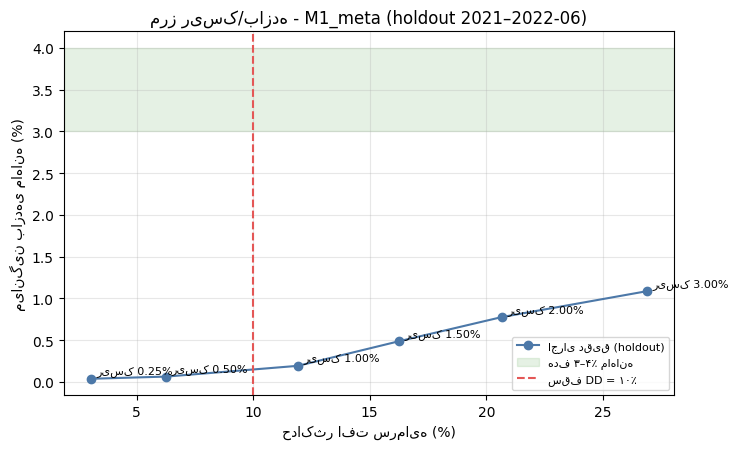

بالاترین ریسکی که DD تیک‌به‌تیک آن زیر ۱۰٪ است: ریسک 0.50%


In [12]:
# ==================================================================================
# Cell 9 — مرز ریسک/بازده و بررسی هدف کاربر (۳–۴٪ ماهانه با DD کمتر از ۱۰٪)
# • اجرای دقیق تیک‌به‌تیک روی holdout برای چند سطح ریسک هر معامله
# • شبیه‌سازی بوت‌استرپ بلوک ماهانه برای احتمال رسیدن به هدف و احتمال DD ≥ ۱۰٪
# ==================================================================================
def selected_signals_ho():
    if SELECTED == "M1_meta":
        return ML_RES["M1_meta"]["sig_ho"]
    if SELECTED == "M2_direct":
        return ML_RES["M2_direct"]["sig_ho"]
    return CANDS[SELECTED][WFO[SELECTED]["frozen"]]


SIG_HO = selected_signals_ho()
RISKS = [0.0025, 0.005, 0.01, 0.015, 0.02, 0.03]
_front = []
for _rk in RISKS:
    _prm = PRM0.copy()
    _prm[P_RISK] = _rk
    _r = run_window(SIG_HO, HO_START, HO_END, prm=_prm)
    _front.append(summarize(_r["tr"], _r["eq"], PRM0[P_EQ0], _r["dd_rel"], _r["dd_abs"], HO_START, HO_END,
                            label=f"ریسک {_rk * 100:.2f}%"))
FRONT = pd.DataFrame(_front)[["strategy", "trades", "net_profit_%", "CAGR_%", "monthly_mean_%", "monthly_median_%",
                              "months_>=3%_%", "maxDD_%", "Calmar", "Sharpe_daily_ann"]].round(3)
display(FRONT.set_index("strategy"))

# ---- بوت‌استرپ بلوکی ماهانه روی R معاملات holdout ----
_base_ho = run_window(SIG_HO, HO_START, HO_END)
_tf = trades_frame(_base_ho["tr"])
R_BY_MONTH = {}
for _m, _g in _tf.groupby(_tf["entry_time"].dt.to_period("M")):
    R_BY_MONTH[str(_m)] = _g["R"].values
for _m in pd.period_range("2021-01", "2022-06", freq="M"):
    R_BY_MONTH.setdefault(str(_m), np.zeros(0))
R_BY_MONTH = dict(sorted(R_BY_MONTH.items()))


def mc_monthly(R_by_month, r, B=4000, seed=0):
    rng = np.random.default_rng(seed)
    M = len(R_by_month)
    eq = np.ones(B)
    peak = np.ones(B)
    maxdd = np.zeros(B)
    mret = np.zeros((B, M))
    for j, (_, Rm) in enumerate(R_by_month.items()):
        n = len(Rm)
        if n == 0:
            continue
        draws = rng.integers(0, n, size=(B, n))
        prod = np.prod(np.clip(1 + r * Rm[draws], 1e-9, None), axis=1)
        mret[:, j] = prod - 1
        eq = eq * prod
        peak = np.maximum(peak, eq)
        maxdd = np.maximum(maxdd, 1 - eq / peak)
    return mret, maxdd


_mc = []
for _rk in RISKS:
    mret, mdd = mc_monthly(R_BY_MONTH, _rk)
    _mc.append({"ریسک هر معامله %": _rk * 100,
                "میانه‌ی بازده‌ی ماهانه %": round(100 * np.median(mret), 2),
                "P(ماه ≥ ۳٪)": round(float((mret >= 0.03).mean()), 3),
                "میانه‌ی DD %": round(100 * np.median(mdd), 2),
                "صدک ۹۵ DD %": round(100 * np.quantile(mdd, 0.95), 2),
                "P(DD ≥ ۱۰٪)": round(float((mdd >= 0.10).mean()), 3),
                "P(میانگین ماهانه ≥ ۳٪)": round(float((mret.mean(axis=1) >= 0.03).mean()), 3)})
MC_TABLE = pd.DataFrame(_mc).set_index("ریسک هر معامله %")
display(MC_TABLE)
print("یادداشت: DD در شبیه‌سازی بر پایان هر ماه سنجیده می‌شود (کمی خوش‌بینانه نسبت به DD تیک‌به‌تیک).")

# ---- نمودار مرز: بازده ماهانه در برابر DD ----
fig, ax = plt.subplots(figsize=(7.5, 4.6))
ax.plot(FRONT["maxDD_%"], FRONT["monthly_mean_%"], marker="o", color="#4C78A8", label="اجرای دقیق (holdout)")
for _, _row in FRONT.iterrows():
    ax.annotate(_row["strategy"], (_row["maxDD_%"], _row["monthly_mean_%"]), fontsize=8,
                xytext=(4, 4), textcoords="offset points")
ax.axhspan(3, 4, color="#54A24B", alpha=0.15, label="هدف ۳–۴٪ ماهانه")
ax.axvline(10, color="#E45756", ls="--", label="سقف DD = ۱۰٪")
ax.set_xlabel("حداکثر افت سرمایه (%)"); ax.set_ylabel("میانگین بازده‌ی ماهانه (%)")
ax.set_title(f"مرز ریسک/بازده - {SELECTED} (holdout 2021–2022-06)")
ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

_best_for_dd = FRONT[FRONT["maxDD_%"] < 10]
print("بالاترین ریسکی که DD تیک‌به‌تیک آن زیر ۱۰٪ است:",
      _best_for_dd["strategy"].iloc[-1] if len(_best_for_dd) else "هیچ‌کدام")

## ۱۱. 🏁 سلول نهایی: بک‌تستر حرفه‌ای تیک‌به‌تیک و گزارش جامع
موتور تیک‌به‌تیک در بخش ۲ تعریف شده است تا همه‌ی آزمایش‌های بالا از **همان** موتور استفاده کنند. این سلول آن موتور را روی استراتژی منجمد انتخاب‌شده در holdout اجرا می‌کند و گزارش کامل تولید می‌کند:
1. پیکربندی موتور و فرض‌های هزینه
2. خلاصه‌ی عملکرد (بازده، DD، Sharpe، Calmar، PF، زمان زیر آب، اکسپوژر)
3. بازده‌ی ماهانه (جدول سال × ماه)
4. تحلیل معاملات: علت خروج، جهت، ساعت ورود، MAE/MFE
5. **حساسیت هزینه و اجرا:** اسپرد ×۱.۵/×۲/×۳، اسلیپیج، تأخیر، کمیسیون، فیلتر اسپرد
6. آمار استنباطی: فاصله‌ی اطمینان بوت‌استرپ، t-test، **آزمون جهت تصادفی** روی همان سیگنال‌ها، DSR و PBO
7. نمودارها: منحنی سرمایه، افت از اوج، بازده ماهانه، توزیع R، نتیجه‌ی آزمون جهت تصادفی
8. داوری هدف با اعداد محاسبه‌شده
9. خروجی: CSV معاملات و ماهانه، و گزارش HTML در `CACHE_DIR/reports`

> **محدودیت‌ها:** فقط یک جفت‌ارز؛ swap ناشناخته؛ عمق بازار و قیمت‌های لیمیت در نظر گرفته نشده‌اند؛ تراکم تیک ۲۰۲۱ متفاوت است؛ و holdout شش ماه است، بنابراین آمار ماهانه کم‌تعداد است.

=== پیکربندی موتور تیک‌به‌تیک ===


,مقدار
پارامتر,
سرمایه‌ی اولیه (USD),10000.0
ریسک هر معامله,0.50% از سرمایه‌ی لحظه‌ای
سقف اهرم,30.0
کمیسیون (USD/لات/طرف),3.5
اسلیپیج (pip، هر طرف),0.1
تأخیر اجرا (ms),1000.0
پنجره‌ی پرشدن (ms),30000.0
فیلتر اسپرد بیشینه (pip),2.0
ورود جدید تا,جمعه ۲۰:۰۰ UTC


=== خلاصه‌ی عملکرد (holdout، تیک‌به‌تیک، ریسک پایه) ===


,M1_meta
trades,172.000
net_profit_%,0.966
CAGR_%,0.645
monthly_mean_%,0.064
monthly_median_%,0.130
monthly_min_%,-2.263
monthly_max_%,2.648
months_>=3%_%,0.000
months_>0_%,50.000
maxDD_%,6.276


=== بازده‌ی ماهانه (%) ===


...

entry_time,0,1,2,3,4,5,6,7,8,9,...,13,14,15,16,17,18,19,20,21,23
تعداد,4.00,2.00,1.00,1.00,1.00,3.00,4.00,56.00,38.00,14.00,...,2.00,2.00,7.00,7.00,4.00,4.00,4.00,1.0,1.00,1.00
میانگین_R,0.39,-1.16,1.55,-1.14,-1.18,-1.15,0.18,0.06,-0.03,0.08,...,0.43,-1.02,0.25,-0.21,0.26,-0.44,-0.23,-1.1,0.26,-1.25
جمع_خالص_USD,77.90,-116.14,77.00,-58.10,-60.48,-171.99,34.05,175.99,-55.90,54.42,...,41.79,-101.23,82.85,-72.93,50.83,-87.09,-45.76,-55.8,12.69,-60.27


=== تحلیل حساسیت هزینه و اجرا (هر سطر یک اجرای کامل تیک‌به‌تیک) ===


,معامله,بازده‌ی کل %,میانگین ماهانه %,DD %,میانگین R,ضریب سود
سناریو,,,,,,
پایه,172,0.97,0.064,6.28,0.0140,1.024
اسپرد ×1.5,172,-0.21,-0.001,7.37,0.0004,0.995
اسپرد ×2,173,-2.34,-0.119,7.60,-0.0245,0.944
اسپرد ×3,173,-2.84,-0.147,7.41,-0.0305,0.932
اسلیپیج = ۰,172,1.51,0.094,6.08,0.0203,1.038
اسلیپیج = ۰.۳ pip,172,-1.00,-0.045,7.62,-0.0089,0.975
تأخیر ۰.۵ ثانیه,172,0.95,0.064,6.34,0.0139,1.024
تأخیر ۳ ثانیه,172,2.35,0.140,5.56,0.0299,1.059
تأخیر ۵ ثانیه,172,2.28,0.135,6.07,0.0291,1.057


=== آمار استنباطی ===


,مقدار
آماره,
میانگین R (holdout),0.014
CI 95% میانگین R (bootstrap),"[-0.1516, 0.1772]"
t-stat میانگین R,0.172
p-value دوطرفه (t-test),0.8638
میانگین R در جهت تصادفی (300 اجرا),-0.0719
p-value یک‌طرفه در برابر جهت تصادفی,0.1033
DSR (از سلول ۸),0.0
PBO پیکربندی‌ها (از سلول ۸),0.039
P(ماه ≥ ۳٪) با بوت‌استرپ ریسک پایه,0.097


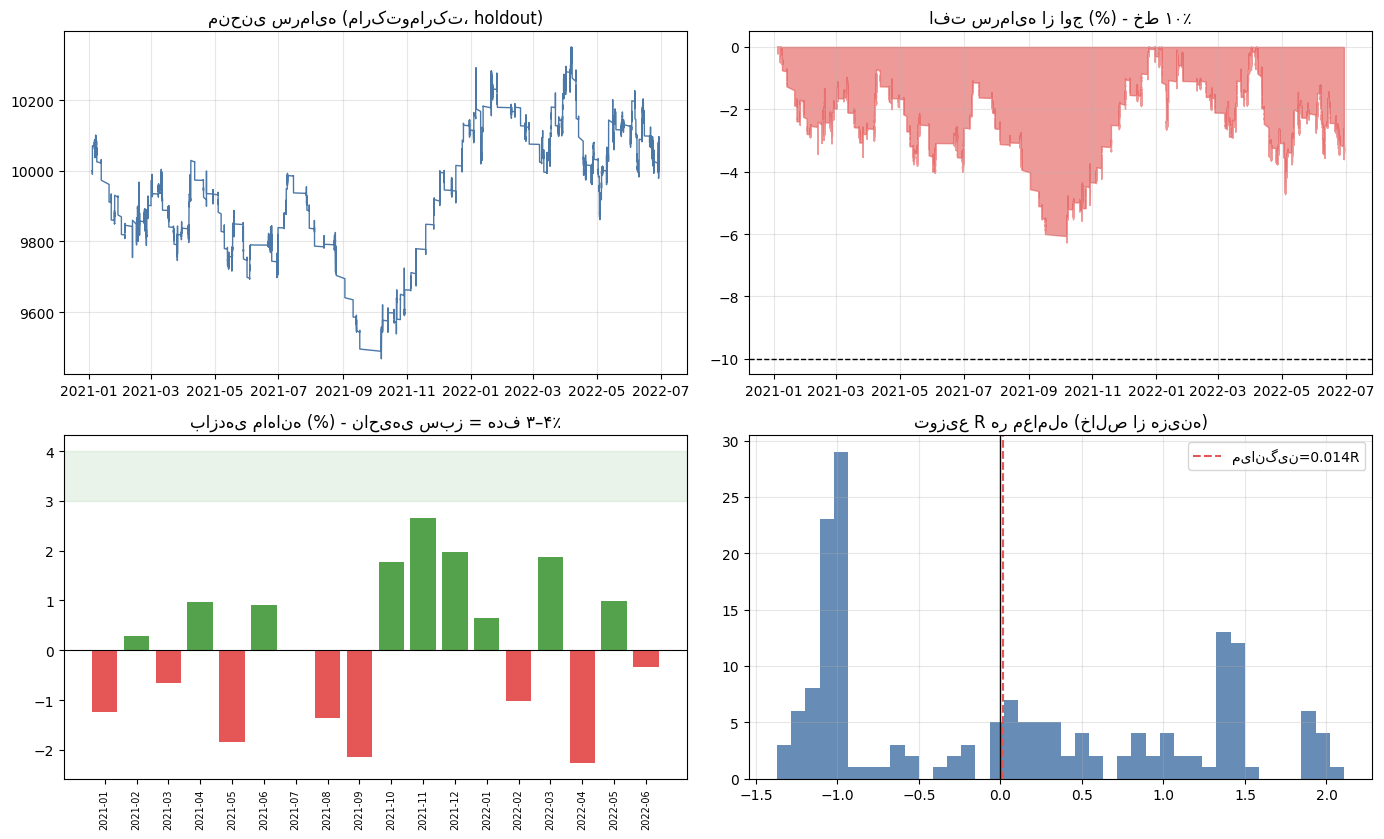

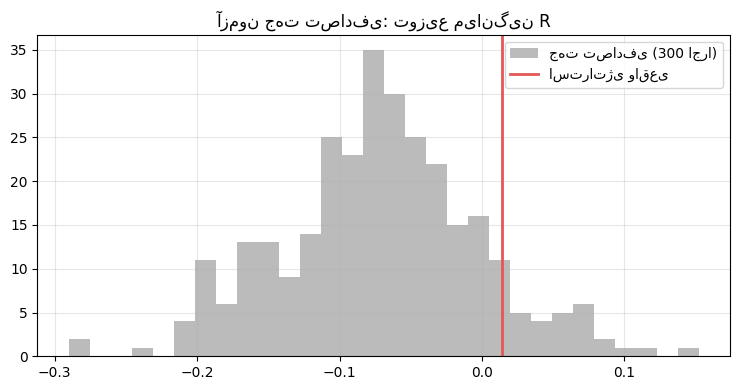

=== داوری هدف ===
  میانگین بازده‌ی ماهانه (holdout، ریسک 0.50%): 0.064%  → هدف ۳–۴٪: خیر
  حداکثر افت سرمایه (تیک‌به‌تیک): 6.28%  → سقف ۱۰٪: بله
  نتیجه: ❌ هدف برآورده نشد
  بزرگ‌ترین ریسکی که DD تیک‌به‌تیک آن زیر ۱۰٪ مانده (از مرز ریسک): ریسک 0.50%
  احتمال (بوت‌استرپ) رسیدن میانگین ماهانه به ۳٪ در ریسک پایه: 0.00%
فایل‌های گزارش: /content/hipo_tick_cache/reports/EURUSD_M1_meta_holdout_report.html | /content/hipo_tick_cache/reports/EURUSD_M1_meta_holdout_charts.png


In [13]:
# ==================================================================================
# Cell 10 — 🏁 بک‌تستر حرفه‌ای تیک‌به‌تیک و گزارش جامع (سلول نهایی)
# استراتژی منجمد انتخابی روی holdout (2021-01 تا 2022-06) • بدون بهینه‌سازی روی این داده
# ==================================================================================
from scipy.stats import ttest_1samp
import base64, io as _io

REPORT_DIR = os.path.join(CACHE_DIR, "reports")
os.makedirs(REPORT_DIR, exist_ok=True)
RUN_TAG = f"{PAIR}_{SELECTED}_holdout"
pd.set_option("display.width", 200)

# ---------- ۱) اجرای پایه: تیک‌به‌تیک، ریسک پیش‌فرض ----------
BASE = run_window(SIG_HO, HO_START, HO_END)
TR = trades_frame(BASE["tr"])
EQ = equity_series(BASE["eq"], PRM0[P_EQ0])
BASE_SUM = summarize(BASE["tr"], BASE["eq"], PRM0[P_EQ0], BASE["dd_rel"], BASE["dd_abs"], HO_START, HO_END,
                     label=SELECTED)

# طول دوره‌ی زیر آب (underwater) بر حسب روز
_peak = EQ.cummax()
_uw = (EQ < _peak).values
_t = EQ.index.values
_longest, _start = 0.0, None
for _i in range(len(_uw)):
    if _uw[_i] and _start is None:
        _start = _t[_i]
    if (not _uw[_i]) and _start is not None:
        _longest = max(_longest, (_t[_i] - _start) / np.timedelta64(1, "D"))
        _start = None
if _start is not None:
    _longest = max(_longest, (_t[-1] - _start) / np.timedelta64(1, "D"))

_months_total = (HO_END - HO_START) / (30.44 * MS_DAY)
_exposure = float(TR["hold_min"].sum() / ((HO_END - HO_START) / MS_MIN)) * 100 if len(TR) else 0.0

CFG_TBL = pd.DataFrame([
    ("سرمایه‌ی اولیه (USD)", PRM0[P_EQ0]), ("ریسک هر معامله", f"{PRM0[P_RISK] * 100:.2f}% از سرمایه‌ی لحظه‌ای"),
    ("سقف اهرم", PRM0[P_MAXLEV]), ("کمیسیون (USD/لات/طرف)", PRM0[P_COMM]),
    ("اسلیپیج (pip، هر طرف)", round(PRM0[P_SLIP] / PIP, 2)), ("تأخیر اجرا (ms)", PRM0[P_LAT]),
    ("پنجره‌ی پرشدن (ms)", PRM0[P_FILLWIN]), ("فیلتر اسپرد بیشینه (pip)", round(PRM0[P_MAXSPREAD] / PIP, 2)),
    ("ورود جدید تا", "جمعه ۲۰:۰۰ UTC"), ("بستن اجباری", "جمعه ۲۰:۳۰ UTC"),
    ("جهت‌گیری", "یک پوزیشن هم‌زمان؛ سیگنال‌های زمانِ باز بودن نادیده گرفته می‌شوند"),
    ("بهره‌ی شبانه (swap)", "نادیده گرفته شده (داده‌ی swap در دسترس نیست)"),
    ("مبنای قیمت", "خرید با ask، فروش با bid؛ همه‌ی خروج‌ها با تیک واقعی"),
], columns=["پارامتر", "مقدار"]).set_index("پارامتر")
print("=== پیکربندی موتور تیک‌به‌تیک ===")
display(CFG_TBL)

# ---------- ۲) خلاصه‌ی عملکرد ----------
_keys = ["trades", "net_profit_%", "CAGR_%", "monthly_mean_%", "monthly_median_%", "monthly_min_%", "monthly_max_%",
         "months_>=3%_%", "months_>0_%", "maxDD_%", "maxDD_usd", "Calmar", "Sharpe_daily_ann", "win_rate_%", "avg_R",
         "t_stat_R", "profit_factor", "avg_net_pips", "avg_hold_h", "commission_usd", "spread_cost_usd_est"]
_sum = {k: BASE_SUM.get(k, np.nan) for k in _keys}
_sum["exposure_%_of_time"] = _exposure
_sum["longest_underwater_days"] = _longest
_sum["trades_per_month"] = BASE_SUM["trades"] / _months_total
SUMMARY_TBL = pd.Series(_sum, name=SELECTED).to_frame()
print("=== خلاصه‌ی عملکرد (holdout، تیک‌به‌تیک، ریسک پایه) ===")
display(SUMMARY_TBL.round(3))

# ---------- ۳) بازده‌ی ماهانه ----------
MR = monthly_returns(BASE["eq"], PRM0[P_EQ0])
MR_TBL = pd.DataFrame({"سال": MR.index.year, "ماه": MR.index.month, "بازده %": (100 * MR.values).round(2)})
MR_PIV = MR_TBL.pivot(index="سال", columns="ماه", values="بازده %")
MR_PIV["سال"] = MR_PIV.sum(axis=1).round(2)
print("=== بازده‌ی ماهانه (%) ===")
display(MR_PIV)

# ---------- ۴) تحلیل معاملات ----------
if len(TR):
    _gx = TR.groupby("exit_reason").agg(تعداد=("R", "size"), میانگین_R=("R", "mean"), برد_درصد=("R", lambda s: 100 * (s > 0).mean()),
                                          جمع_خالص_USD=("net", "sum"))
    _gh = TR.groupby(TR["entry_time"].dt.hour).agg(تعداد=("R", "size"), میانگین_R=("R", "mean"), جمع_خالص_USD=("net", "sum"))
    _gd = TR.groupby(np.where(TR["dir"] > 0, "خرید", "فروش")).agg(تعداد=("R", "size"), میانگین_R=("R", "mean"),
                                                                    برد_درصد=("R", lambda s: 100 * (s > 0).mean()))
    _mae = (TR["mae"] / PIP)
    _mfe = (TR["mfe"] / PIP)
    print("=== علت خروج ===")
    display(_gx.round(3))
    print("=== جهت معامله ===")
    display(_gd.round(3))
    print(f"میانگین MAE: {_mae.mean():.1f} pip | میانگین MFE: {_mfe.mean():.1f} pip | میانه‌ی مدت نگهداری: {TR['hold_min'].median() / 60:.1f} ساعت")
    print("=== عملکرد بر حسب ساعت ورود (UTC) ===")
    display(_gh.round(2).T)

# ---------- ۵) حساسیت به هزینه، تأخیر و فیلتر اسپرد ----------
SCEN = [
    ("پایه", {}), ("اسپرد ×1.5", {P_SPREADMULT: 1.5}), ("اسپرد ×2", {P_SPREADMULT: 2.0}),
    ("اسپرد ×3", {P_SPREADMULT: 3.0}), ("اسلیپیج = ۰", {P_SLIP: 0.0}), ("اسلیپیج = ۰.۳ pip", {P_SLIP: 0.3 * PIP}),
    ("تأخیر ۰.۵ ثانیه", {P_LAT: 500}), ("تأخیر ۳ ثانیه", {P_LAT: 3000}), ("تأخیر ۵ ثانیه", {P_LAT: 5000}),
    ("کمیسیون = ۰", {P_COMM: 0.0}), ("کمیسیون = ۷ دلار", {P_COMM: 7.0}),
    ("بدون فیلتر اسپرد", {P_MAXSPREAD: 0.0}), ("فیلتر اسپرد ۱ pip", {P_MAXSPREAD: 1.0 * PIP}),
]
_scen_rows = []
for _name, _chg in SCEN:
    _p = PRM0.copy()
    for _k, _v in _chg.items():
        _p[_k] = _v
    _r = run_window(SIG_HO, HO_START, HO_END, prm=_p)
    _s = summarize(_r["tr"], _r["eq"], PRM0[P_EQ0], _r["dd_rel"], _r["dd_abs"], HO_START, HO_END, label=_name)
    _scen_rows.append({"سناریو": _name, "معامله": _s["trades"], "بازده‌ی کل %": round(_s["net_profit_%"], 2),
                       "میانگین ماهانه %": round(_s["monthly_mean_%"], 3), "DD %": round(_s["maxDD_%"], 2),
                       "میانگین R": round(_s.get("avg_R", np.nan), 4), "ضریب سود": round(_s.get("profit_factor", np.nan), 3)})
SCEN_TBL = pd.DataFrame(_scen_rows).set_index("سناریو")
print("=== تحلیل حساسیت هزینه و اجرا (هر سطر یک اجرای کامل تیک‌به‌تیک) ===")
display(SCEN_TBL)

# ---------- ۶) آمار استنباطی ----------
_Rv = TR["R"].values if len(TR) else np.array([0.0])
_ci = boot_ci(_Rv, np.mean, B=3000)
_tt = ttest_1samp(_Rv, 0.0) if len(_Rv) > 2 else None
_rng = np.random.default_rng(7)
_null_means = []
for _b in range(300):
    _sc = SIG_HO.copy()
    _sc["dir"] = _rng.choice([-1.0, 1.0], size=len(_sc))  # همان زمان/فاصله‌ی SL/TP/نگهداری، جهت تصادفی
    _rr = run_window(_sc, HO_START, HO_END)
    _tn = trades_frame(_rr["tr"])
    if len(_tn):
        _null_means.append(_tn["R"].mean())
_null_means = np.array(_null_means) if _null_means else np.array([0.0])
_p_null = float((_null_means >= _Rv.mean()).mean())
STAT_TBL = pd.DataFrame([
    ("میانگین R (holdout)", round(_Rv.mean(), 4)), ("CI 95% میانگین R (bootstrap)", f"[{_ci[0]:.4f}, {_ci[1]:.4f}]"),
    ("t-stat میانگین R", round(float(_tt.statistic), 3) if _tt is not None else np.nan),
    ("p-value دوطرفه (t-test)", round(float(_tt.pvalue), 4) if _tt is not None else np.nan),
    ("میانگین R در جهت تصادفی (300 اجرا)", round(float(_null_means.mean()), 4)),
    ("p-value یک‌طرفه در برابر جهت تصادفی", round(_p_null, 4)),
    ("DSR (از سلول ۸)", round(float(dsr_p), 3)), ("PBO پیکربندی‌ها (از سلول ۸)", round(float(pbo), 3)),
    ("P(ماه ≥ ۳٪) با بوت‌استرپ ریسک پایه", round(float((mc_monthly(R_BY_MONTH, PRM0[P_RISK])[0] >= 0.03).mean()), 3)),
], columns=["آماره", "مقدار"]).set_index("آماره")
print("=== آمار استنباطی ===")
display(STAT_TBL)

# ---------- ۷) نمودارهای گزارش ----------
fig, axes = plt.subplots(2, 2, figsize=(14, 8.5))
ax = axes[0, 0]
ax.plot(EQ.index, EQ.values, color="#4C78A8", lw=1)
ax.set_title("منحنی سرمایه (مارک‌تو‌مارکت، holdout)"); ax.grid(alpha=0.3)
ax = axes[0, 1]
_dd = 100 * (EQ.cummax() - EQ) / EQ.cummax()
ax.fill_between(_dd.index, -_dd.values, 0, color="#E45756", alpha=0.6)
ax.axhline(-10, color="black", ls="--", lw=1); ax.set_title("افت سرمایه از اوج (%) - خط ۱۰٪"); ax.grid(alpha=0.3)
ax = axes[1, 0]
_mrv = 100 * MR.values
ax.bar([str(p) for p in MR.index], _mrv, color=np.where(_mrv >= 0, "#54A24B", "#E45756"))
ax.axhspan(3, 4, color="#54A24B", alpha=0.12); ax.axhline(0, color="black", lw=0.8)
ax.set_title("بازده‌ی ماهانه (%) - ناحیه‌ی سبز = هدف ۳–۴٪"); ax.tick_params(axis="x", rotation=90, labelsize=7)
ax = axes[1, 1]
ax.hist(_Rv, bins=40, color="#4C78A8", alpha=0.85)
ax.axvline(0, color="black", lw=1); ax.axvline(_Rv.mean(), color="#E45756", ls="--", label=f"میانگین={_Rv.mean():.3f}R")
ax.set_title("توزیع R هر معامله (خالص از هزینه)"); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
_png = os.path.join(REPORT_DIR, f"{RUN_TAG}_charts.png")
plt.savefig(_png, dpi=110)
plt.show()

fig2, ax2 = plt.subplots(figsize=(7.5, 4))
ax2.hist(_null_means, bins=30, color="#BBBBBB", label="جهت تصادفی (300 اجرا)")
ax2.axvline(_Rv.mean(), color="#E45756", lw=2, label="استراتژی واقعی")
ax2.set_title("آزمون جهت تصادفی: توزیع میانگین R"); ax2.legend(); ax2.grid(alpha=0.3)
plt.tight_layout(); plt.show()

# ---------- ۸) داوری نهایی (با اعداد محاسبه‌شده) ----------
_mm = BASE_SUM["monthly_mean_%"]
_dd_pct = BASE_SUM["maxDD_%"]
_tgt_ok = _mm >= 3.0
_dd_ok = _dd_pct < 10.0
_verdict = ("✅ هدف برآورده شد" if (_tgt_ok and _dd_ok) else "❌ هدف برآورده نشد")
print("=== داوری هدف ===")
print(f"  میانگین بازده‌ی ماهانه (holdout، ریسک {PRM0[P_RISK] * 100:.2f}%): {_mm:.3f}%  → هدف ۳–۴٪: {'بله' if _tgt_ok else 'خیر'}")
print(f"  حداکثر افت سرمایه (تیک‌به‌تیک): {_dd_pct:.2f}%  → سقف ۱۰٪: {'بله' if _dd_ok else 'خیر'}")
print(f"  نتیجه: {_verdict}")
print(f"  بزرگ‌ترین ریسکی که DD تیک‌به‌تیک آن زیر ۱۰٪ مانده (از مرز ریسک): {_best_for_dd['strategy'].iloc[-1] if len(_best_for_dd) else '—'}")
print(f"  احتمال (بوت‌استرپ) رسیدن میانگین ماهانه به ۳٪ در ریسک پایه: {100 * float((mc_monthly(R_BY_MONTH, PRM0[P_RISK])[0].mean(axis=1) >= 0.03).mean()):.2f}%")

# ---------- ۹) خروجی‌ها: CSV و گزارش HTML ----------
TR.to_csv(os.path.join(REPORT_DIR, f"{RUN_TAG}_trades.csv"), index=False)
MR_TBL.to_csv(os.path.join(REPORT_DIR, f"{RUN_TAG}_monthly.csv"), index=False)
_buf = _io.BytesIO()
fig.savefig(_buf, format="png", dpi=90)
_b64 = base64.b64encode(_buf.getvalue()).decode()
_html = f"""<html><head><meta charset='utf-8'><title>{RUN_TAG}</title>
<style>body{{font-family:Tahoma,sans-serif;direction:rtl;margin:24px}}table{{border-collapse:collapse;font-size:12px}}
td,th{{border:1px solid #ccc;padding:3px 6px}}h2{{margin-top:28px}}</style></head><body>
<h1>گزارش بک‌تست تیک‌به‌تیک - {PAIR} - {SELECTED}</h1>
<p>دوره‌ی holdout: {pd.Timestamp(HO_START, unit='ms').date()} تا {pd.Timestamp(HO_END, unit='ms').date()} | داده: Dukascopy (تیک bid/ask)</p>
<h2>پیکربندی</h2>{CFG_TBL.to_html()}
<h2>خلاصه</h2>{SUMMARY_TBL.round(3).to_html()}
<h2>بازده‌ی ماهانه (%)</h2>{MR_PIV.to_html()}
<h2>حساسیت</h2>{SCEN_TBL.to_html()}
<h2>آمار استنباطی</h2>{STAT_TBL.to_html()}
<h2>نمودارها</h2><img style='max-width:100%' src='data:image/png;base64,{_b64}'/>
<h2>داوری</h2><p>{_verdict} | میانگین ماهانه {_mm:.3f}% | حداکثر DD {_dd_pct:.2f}%</p>
</body></html>"""
_html_path = os.path.join(REPORT_DIR, f"{RUN_TAG}_report.html")
with open(_html_path, "w", encoding="utf-8") as fh:
    fh.write(_html)
print("فایل‌های گزارش:", _html_path, "|", _png)